# Store Split Notebook

## Set Up Environment and Imports

In [399]:
from pathlib import Path

import pandas as pd

## Define Configuration and Constants

In [400]:
CONFIG = {
    "csv_path": Path("eval_results_normalized.csv"),
    "with_store_label": "With_Store",
    "no_store_label": "No_Store",
}

EXPECTED_COLUMNS = {"Condition", "Value"}

## Implement Core Functions

In [401]:
from typing import Iterable, Tuple


def load_results(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path)


def clean_condition(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    if "Condition" in cleaned.columns:
        cleaned["Condition"] = cleaned["Condition"].astype(str).str.strip()
    return cleaned


def validate_schema(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def validate_conditions(df: pd.DataFrame, expected: Iterable[str]) -> None:
    actual = set(df["Condition"].dropna().unique())
    unexpected = sorted(actual - set(expected))
    if unexpected:
        raise ValueError(f"Unexpected Condition values: {unexpected}")


def split_by_condition(
    df: pd.DataFrame,
    with_store_label: str,
    no_store_label: str,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_with_store = df[df["Condition"] == with_store_label].reset_index(drop=True)
    df_no_store = df[df["Condition"] == no_store_label].reset_index(drop=True)
    return df_with_store, df_no_store


df_raw = load_results(CONFIG["csv_path"])
validate_schema(df_raw, EXPECTED_COLUMNS)

df_clean = clean_condition(df_raw)
validate_conditions(df_clean, [CONFIG["with_store_label"], CONFIG["no_store_label"]])

df_with_store, df_no_store = split_by_condition(
    df_clean,
    CONFIG["with_store_label"],
    CONFIG["no_store_label"],
)

print("With store shape:", df_with_store.shape)
print("No store shape:", df_no_store.shape)

display(df_with_store.head())
display(df_no_store.head())

With store shape: (4122, 11)
No store shape: (3200, 11)


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Average_Accuracy,0.9500,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Variance_Raw_Score,0.2778,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,StdDev_Raw_Score,0.5270,NaN
3,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,EFR_Extraction_Failure_Rate,0.0300,NaN
4,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,AFR_Answer_Flip_Rate,0.0200,NaN


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Average_Accuracy,0.2100,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Variance_Raw_Score,0.7667,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,StdDev_Raw_Score,0.8756,NaN
3,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,EFR_Extraction_Failure_Rate,0.0300,NaN
4,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,AFR_Answer_Flip_Rate,0.0400,NaN


In [402]:
metric_name = "Average_Accuracy"
model_column = "Model"
metric_column = "Summary_Metric"

missing_columns = [col for col in [model_column, metric_column, "Condition", "Value"] if col not in df_clean.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

rename_map = {
    "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no thinking)",
    "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no thinking)",
}

plot_df = df_clean.copy()
plot_df[model_column] = plot_df[model_column].replace(rename_map)

plot_df = plot_df[plot_df[metric_column].astype(str).str.strip().str.lower() == metric_name.lower()]

if plot_df.empty:
    raise ValueError(f"No rows found for {metric_column}={metric_name}")

avg_with_store = (
    plot_df[plot_df["Condition"] == CONFIG["with_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "with_store"})
)

avg_no_store = (
    plot_df[plot_df["Condition"] == CONFIG["no_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "no_store"})
)

avg_compare = avg_with_store.merge(avg_no_store, on=model_column, how="outer")

print("Average compare (first rows):")
display(avg_compare.head())

Average compare (first rows):


,Model,with_store,no_store
0,gemma3:1b,0.587778,0.380833
1,gemma4:e2b,0.785227,0.502273
2,llama3.2:1b,0.390556,0.196944
3,ministral-3:3b,0.822727,0.560227
4,qwen3:4b (no thinking),0.828636,0.559091


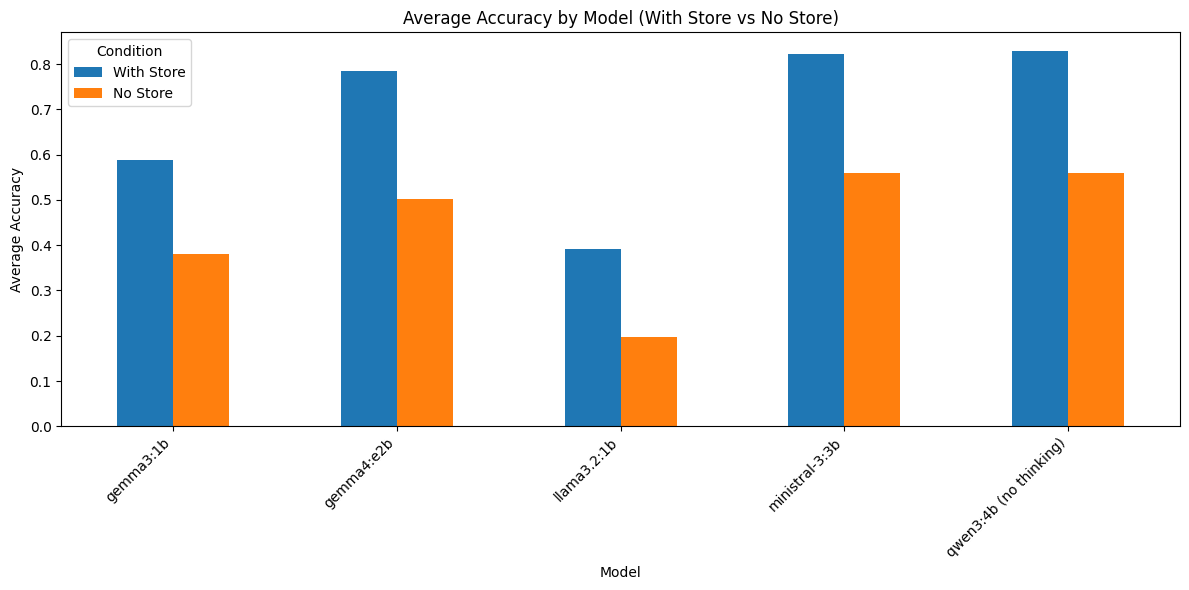

In [403]:
import matplotlib.pyplot as plt

plot_compare = avg_compare.copy()
plot_compare = plot_compare.sort_values(by=model_column).set_index(model_column)

for column in ["with_store", "no_store"]:
    if column not in plot_compare.columns:
        plot_compare[column] = float("nan")

ax = plot_compare[["with_store", "no_store"]].plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_title("Average Accuracy by Model (With Store vs No Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.close(ax.figure)


Condition          scenario_type  no_store  with_store
0                         absurd  0.449750     0.81075
1                absurd_temporal  0.396750     0.73300
2          absurd_temporal_noise  0.416000     0.75650
3             belief_maintenance  0.607500     0.85525
4                      grounding  0.404250     0.45800
5                           hard  0.395833     0.54250


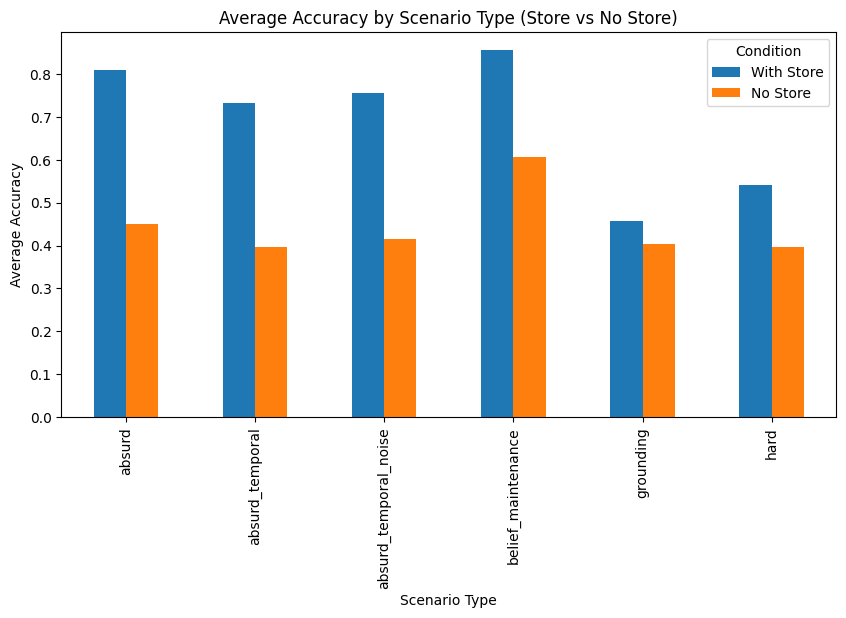

In [404]:
scenario_types = ["grounding", "belief_maintenance", "absurd", "absurd_temporal", "absurd_temporal_noise", "2hop", "trace_selection", "hard"]

scenario_df = df_clean.copy()

def extract_scenario_type(domain: str) -> str:
    domain = str(domain).strip()
    for scenario_type in sorted(scenario_types, key=len, reverse=True):
        if domain.endswith(f"_{scenario_type}"):
            return scenario_type
    return "unknown"

scenario_df["scenario_type"] = scenario_df["Domain"].apply(extract_scenario_type)

scenario_df = scenario_df[
    (scenario_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy")
    & (scenario_df["scenario_type"].isin(scenario_types))
]

scenario_avg = (
    scenario_df.groupby(["scenario_type", "Condition"], as_index=False)["Value"]
    .mean()
)

scenario_pivot = scenario_avg.pivot(
    index="scenario_type",
    columns="Condition",
    values="Value",
).reset_index()

scenario_pivot = scenario_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]: "no_store",
    }
)

ax = scenario_pivot.plot(
    x="scenario_type",
    y=["with_store", "no_store"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Average Accuracy by Scenario Type (Store vs No Store)")
ax.set_xlabel("Scenario Type")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")

print(scenario_pivot)

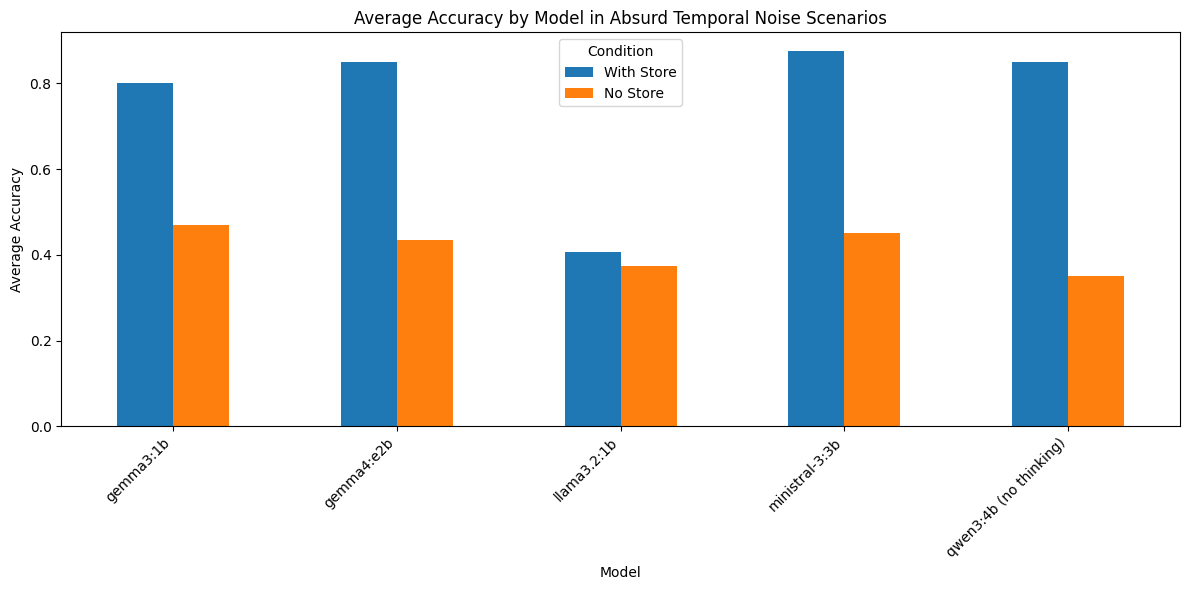

Condition,no_store,with_store
Model,,
gemma3:1b,0.470,0.8000
gemma4:e2b,0.435,0.8500
llama3.2:1b,0.375,0.4075
ministral-3:3b,0.450,0.8750
qwen3:4b (no thinking),0.350,0.8500


In [405]:
import matplotlib.pyplot as plt

noise_suffix = "absurd_temporal_noise"
noise_df = df_clean.copy()
noise_df[model_column] = noise_df[model_column].replace(rename_map)

required_noise_columns = [model_column, "Domain", "Condition", "Summary_Metric", "Value"]
missing_noise_columns = [col for col in required_noise_columns if col not in noise_df.columns]
if missing_noise_columns:
    raise ValueError(f"Missing required columns for absurd_temporal_noise chart: {missing_noise_columns}")

noise_df = noise_df[
    noise_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()
noise_df = noise_df[noise_df["Domain"].astype(str).str.endswith(noise_suffix)]

if noise_df.empty:
    raise ValueError(f"No rows found for domains ending with {noise_suffix}")

noise_summary = (
    noise_df.groupby([model_column, "Condition"], as_index=False)["Value"]
    .mean()
)

noise_pivot = noise_summary.pivot(
    index=model_column,
    columns="Condition",
    values="Value",
).rename(
    columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]: "no_store",
    }
)

for column in ["with_store", "no_store"]:
    if column not in noise_pivot.columns:
        noise_pivot[column] = float("nan")

noise_pivot = noise_pivot.sort_index()
ax = noise_pivot[["with_store", "no_store"]].plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_title("Average Accuracy by Model in Absurd Temporal Noise Scenarios")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.close(ax.figure)

display(noise_pivot)


In [406]:
per_run_var_df = df_clean.copy()
per_run_var_df[model_column] = per_run_var_df[model_column].replace(rename_map)

per_run_var_df = per_run_var_df[
    per_run_var_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
]

# Extract scenario type
per_run_var_df["scenario_type"] = per_run_var_df["Domain"].apply(extract_scenario_type)

per_run_var_df = per_run_var_df[per_run_var_df["scenario_type"].isin(scenario_types)]

# Per-model, per-scenario, per-condition: std of Average_Accuracy across individual data points
per_run_var = (
    per_run_var_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .std()
    .rename(columns={"Value": "std_accuracy"})
)

per_run_var_pivot = per_run_var.pivot_table(
    index=[model_column, "scenario_type"],
    columns="Condition",
    values="std_accuracy",
).reset_index()

per_run_var_pivot.columns.name = None
per_run_var_pivot = per_run_var_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]: "no_store",
    }
)

if "with_store" in per_run_var_pivot.columns and "no_store" in per_run_var_pivot.columns:
    per_run_var_pivot["delta_var"] = (
        per_run_var_pivot["with_store"] - per_run_var_pivot["no_store"]
    )

per_run_var_pivot = per_run_var_pivot.sort_values(by=[model_column, "scenario_type"])

print("Per-Model, Per-Scenario Type: Std Dev of Accuracy across Runs (Store vs No Store):")
display(per_run_var_pivot)

Per-Model, Per-Scenario Type: Std Dev of Accuracy across Runs (Store vs No Store):


,Model,scenario_type,no_store,with_store,delta_var
0,gemma3:1b,absurd,0.213738,0.240476,0.026738
1,gemma3:1b,absurd_temporal,0.117587,0.203255,0.085667
2,gemma3:1b,absurd_temporal_noise,0.047610,0.182574,0.134965
3,gemma3:1b,belief_maintenance,0.105754,0.128779,0.023025
4,gemma3:1b,grounding,0.120238,0.111867,-0.008371
5,gemma4:e2b,absurd,0.295172,0.304862,0.009690
6,gemma4:e2b,absurd_temporal,0.284153,0.163527,-0.120626
7,gemma4:e2b,absurd_temporal_noise,0.244745,0.173205,-0.071540
8,gemma4:e2b,belief_maintenance,0.307292,0.017728,-0.289564
9,gemma4:e2b,grounding,0.268900,0.222032,-0.046868


In [407]:
# Check observation counts per model/scenario/condition
obs_counts = (
    per_run_var_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .count()
    .rename(columns={"Value": "n_observations"})
)

obs_counts_pivot = obs_counts.pivot_table(
    index=[model_column, "scenario_type"],
    columns="Condition",
    values="n_observations",
).reset_index()

obs_counts_pivot.columns.name = None
obs_counts_pivot = obs_counts_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store_n",
        CONFIG["no_store_label"]: "no_store_n",
    }
)

print("Observation counts per Model, Scenario Type, Condition:")
display(obs_counts_pivot)

Observation counts per Model, Scenario Type, Condition:


,Model,scenario_type,no_store_n,with_store_n
0,gemma3:1b,absurd,8.0,8.0
1,gemma3:1b,absurd_temporal,8.0,8.0
2,gemma3:1b,absurd_temporal_noise,4.0,4.0
3,gemma3:1b,belief_maintenance,8.0,8.0
4,gemma3:1b,grounding,8.0,8.0
5,gemma4:e2b,absurd,8.0,8.0
6,gemma4:e2b,absurd_temporal,8.0,8.0
7,gemma4:e2b,absurd_temporal_noise,4.0,4.0
8,gemma4:e2b,belief_maintenance,8.0,8.0
9,gemma4:e2b,grounding,8.0,8.0


In [408]:
# Per-model × Scenario-type accuracy table (with_store vs no_store)
per_model_scenario_df = df_clean.copy()
per_model_scenario_df[model_column] = per_model_scenario_df[model_column].replace(rename_map)

per_model_scenario_df = per_model_scenario_df[
    per_model_scenario_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
]

per_model_scenario_df["scenario_type"] = per_model_scenario_df["Domain"].apply(extract_scenario_type)
per_model_scenario_df = per_model_scenario_df[per_model_scenario_df["scenario_type"].isin(scenario_types)]

per_model_avg = (
    per_model_scenario_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .mean()
)

# Pivot so each model has columns like grounding_With_Store, grounding_No_Store, etc.
per_model_pivot = per_model_avg.pivot_table(
    index=model_column,
    columns=["scenario_type", "Condition"],
    values="Value",
)

# Flatten multiindex columns
per_model_pivot.columns = [f"{sc}_{cond}" for sc, cond in per_model_pivot.columns]
per_model_pivot = per_model_pivot.reset_index().sort_values(by=model_column)

print("Per-model by scenario-type Average Accuracy (columns: <scenario>_<Condition>):")
display(per_model_pivot)

Per-model by scenario-type Average Accuracy (columns: <scenario>_<Condition>):


,Model,absurd_No_Store,absurd_With_Store,absurd_temporal_No_Store,absurd_temporal_With_Store,absurd_temporal_noise_No_Store,absurd_temporal_noise_With_Store,belief_maintenance_No_Store,belief_maintenance_With_Store,grounding_No_Store,grounding_With_Store,hard_No_Store,hard_With_Store
0,gemma3:1b,0.44625,0.73000,0.38375,0.64625,0.470,0.8000,0.37875,0.74875,0.27000,0.12000,NaN,NaN
1,gemma4:e2b,0.64875,0.88375,0.50500,0.85625,0.435,0.8500,0.65000,0.99000,0.40750,0.62875,0.33375,0.5350
2,llama3.2:1b,0.17000,0.49000,0.14500,0.43750,0.375,0.4075,0.35250,0.56750,0.03125,0.05875,NaN,NaN
3,ministral-3:3b,0.54250,0.96750,0.49375,0.85375,0.450,0.8750,0.77500,0.99125,0.59625,0.72750,0.44875,0.5475
4,qwen3:4b (no thinking),0.44125,0.98250,0.45625,0.87125,0.350,0.8500,0.88125,0.97875,0.71625,0.75500,0.40500,0.5450


Comparison: With_Store v15  vs No_Store v1 (per model+domain)


,Model,Domain,with_store_v15,no_store_v1,delta_v15_v1,n_with_store_v15,n_no_store_v1
32,gemma4:e2b,loan_absurd,0.565,0.975,-0.410,2,2
9,gemma3:1b,crime_scene_grounding,0.035,0.345,-0.310,2,2
14,gemma3:1b,loan_grounding,0.115,0.310,-0.195,2,2
81,ministral-3:3b,loan_hard,0.695,0.820,-0.125,2,2
56,llama3.2:1b,loan_absurd_temporal_noise,0.300,0.400,-0.100,1,1
...,...,...,...,...,...,...,...
78,ministral-3:3b,loan_absurd_temporal_noise,1.000,0.400,0.600,1,1
28,gemma4:e2b,crime_scene_absurd_temporal_noise,0.900,0.300,0.600,1,1
101,qwen3:4b (no thinking),loan_absurd_temporal,1.000,0.380,0.620,2,2
100,qwen3:4b (no thinking),loan_absurd,1.000,0.375,0.625,2,2


Model-level mean accuracies (v15 vs v1):


,Model,with_store_v15,no_store_v1
0,gemma3:1b,0.609000,0.389750
1,gemma4:e2b,0.790625,0.496667
2,llama3.2:1b,0.392250,0.214750
3,ministral-3:3b,0.827083,0.551042
4,qwen3:4b (no thinking),0.830417,0.541667


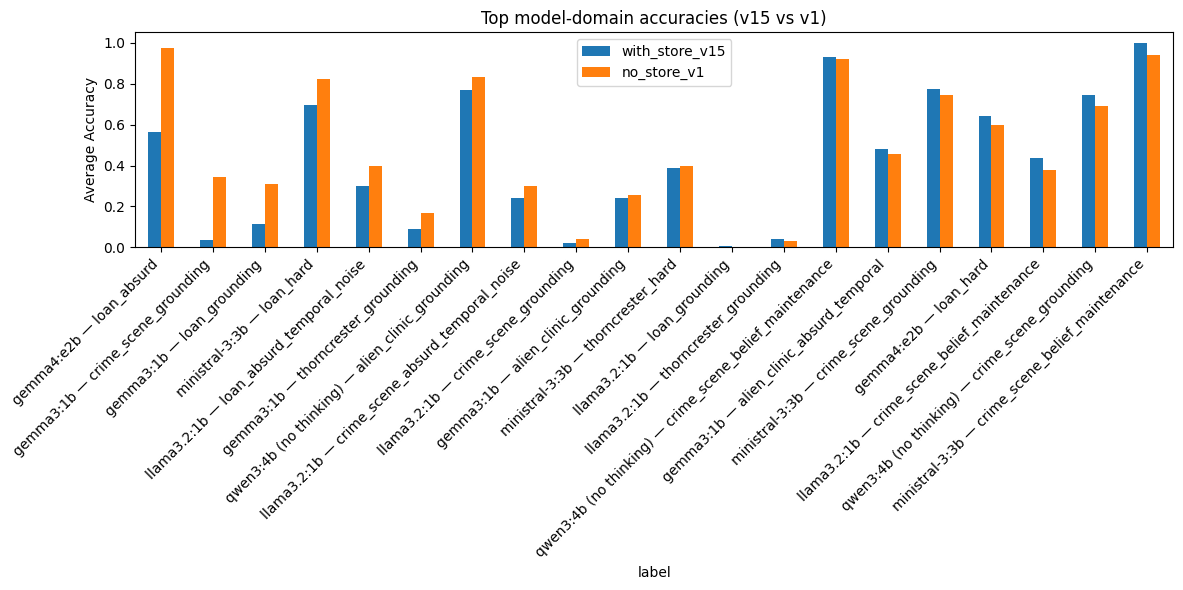

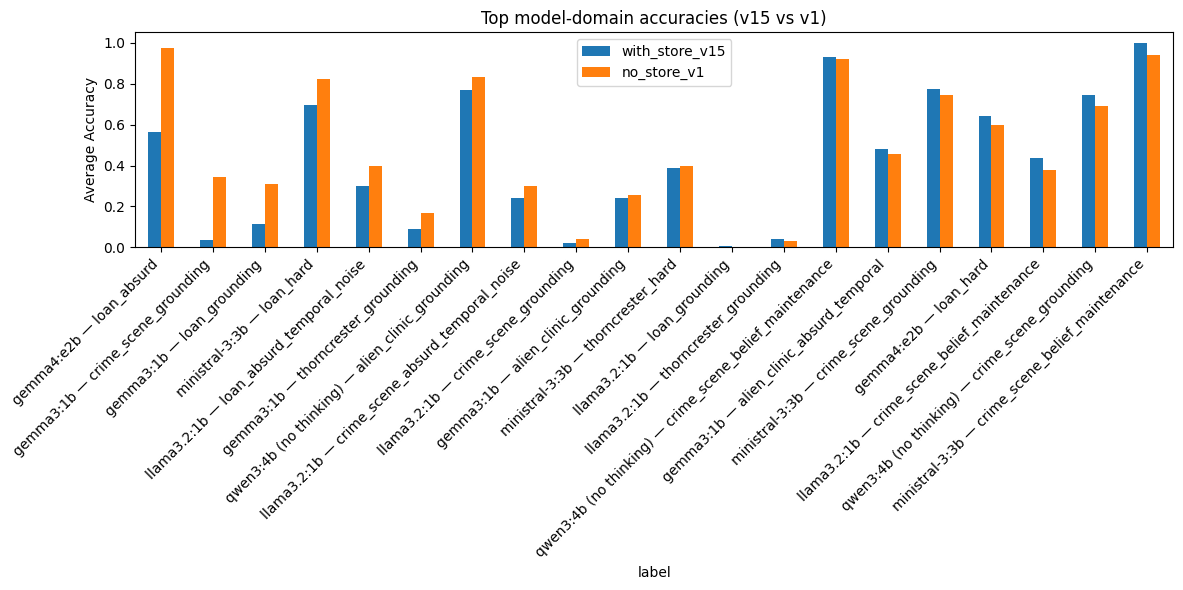

In [409]:
# Compare With_Store v15 vs No_Store v1
comp = df_clean.copy()
comp[model_column] = comp[model_column].replace(rename_map)
comp = comp[comp["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"]

# ensure scenario_type exists
if "scenario_type" not in comp.columns:
    comp["scenario_type"] = comp["Domain"].apply(extract_scenario_type)

# Build masks safely depending on whether Prompt_Ver exists
if "Prompt_Ver" in comp.columns:
    store_mask = (comp["Condition"] == CONFIG["with_store_label"]) & (comp["Prompt_Ver"] == "v15")
    no_store_mask = (comp["Condition"] == CONFIG["no_store_label"]) & (comp["Prompt_Ver"] == "v1")
else:
    store_mask = comp["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp["Condition"] == CONFIG["no_store_label"]

store_grp = (
    comp[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v15"})
)
no_store_grp = (
    comp[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v1"})
)

merge_v15 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v15["delta_v15_v1"] = merge_v15["with_store_v15"] - merge_v15["no_store_v1"]

# counts
counts_store = comp[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_with_store_v15"})
counts_no = comp[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_no_store_v1"})
merge_v15 = merge_v15.merge(counts_store, on=[model_column, "Domain"], how="left").merge(counts_no, on=[model_column, "Domain"], how="left")

print("Comparison: With_Store v15  vs No_Store v1 (per model+domain)")
display(merge_v15.sort_values(by="delta_v15_v1"))

# Model-level averages for inspection (no duplicate plotting here)
model_level = merge_v15.groupby(model_column, as_index=False)[["with_store_v15", "no_store_v1"]].mean()
# handle missing columns
if "with_store_v15" not in model_level.columns:
    model_level["with_store_v15"] = float('nan')
if "no_store_v1" not in model_level.columns:
    model_level["no_store_v1"] = float('nan')

print("Model-level mean accuracies (v15 vs v1):")
display(model_level)

# Top model-domain rows by negative delta, plot their accuracies side-by-side
top = merge_v15.sort_values(by="delta_v15_v1").head(20).copy()
top['label'] = top[model_column].astype(str) + ' — ' + top['Domain'].astype(str)
fig2, ax2 = plt.subplots(figsize=(12, 6))
# create DataFrame for plotting
top_plot = top[["label", "with_store_v15", "no_store_v1"]].set_index("label")
top_plot.plot.bar(ax=ax2)
ax2.set_title('Top model-domain accuracies (v15 vs v1)')
ax2.set_ylabel('Average Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
display(fig2)

Comparison: With_Store v16  vs No_Store v2 (per model+domain)


,Model,Domain,with_store_v16,no_store_v2,delta_v16_v2,n_with_store_v16,n_no_store_v2
32,gemma4:e2b,loan_absurd,0.565,0.975,-0.410,2,2
9,gemma3:1b,crime_scene_grounding,0.035,0.345,-0.310,2,2
14,gemma3:1b,loan_grounding,0.115,0.310,-0.195,2,2
81,ministral-3:3b,loan_hard,0.695,0.820,-0.125,2,2
56,llama3.2:1b,loan_absurd_temporal_noise,0.300,0.400,-0.100,1,1
...,...,...,...,...,...,...,...
78,ministral-3:3b,loan_absurd_temporal_noise,1.000,0.400,0.600,1,1
28,gemma4:e2b,crime_scene_absurd_temporal_noise,0.900,0.300,0.600,1,1
101,qwen3:4b (no thinking),loan_absurd_temporal,1.000,0.380,0.620,2,2
100,qwen3:4b (no thinking),loan_absurd,1.000,0.375,0.625,2,2


Model-level mean accuracies (v16 vs v2):


,Model,with_store_v16,no_store_v2
0,gemma3:1b,0.609000,0.389750
1,gemma4:e2b,0.790625,0.496667
2,llama3.2:1b,0.392250,0.214750
3,ministral-3:3b,0.827083,0.551042
4,qwen3:4b (no thinking),0.830417,0.541667


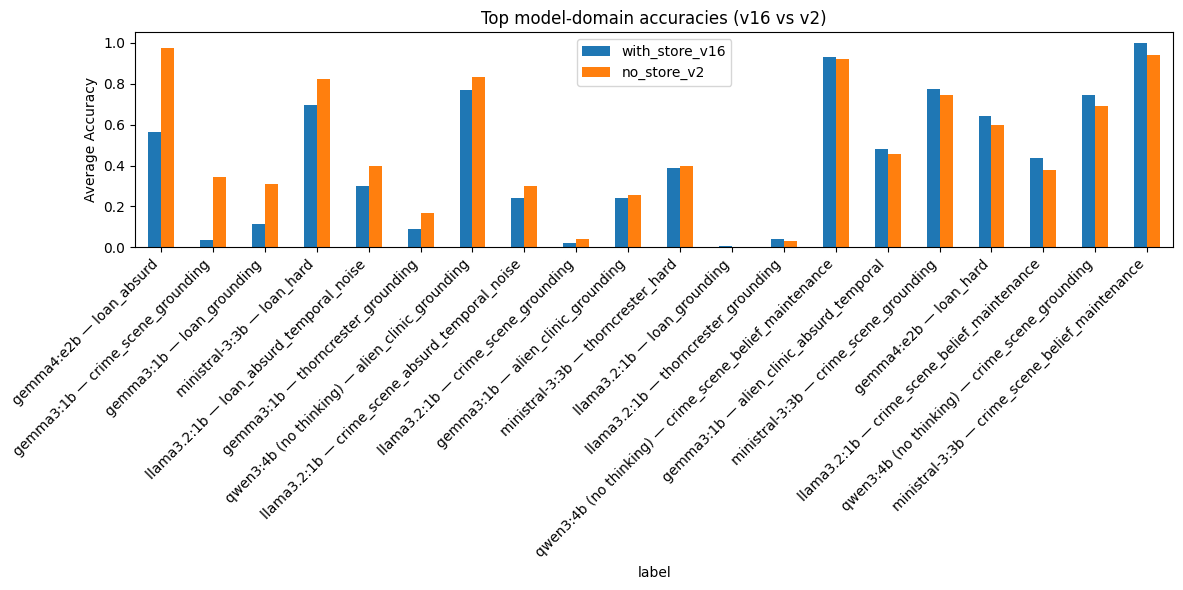

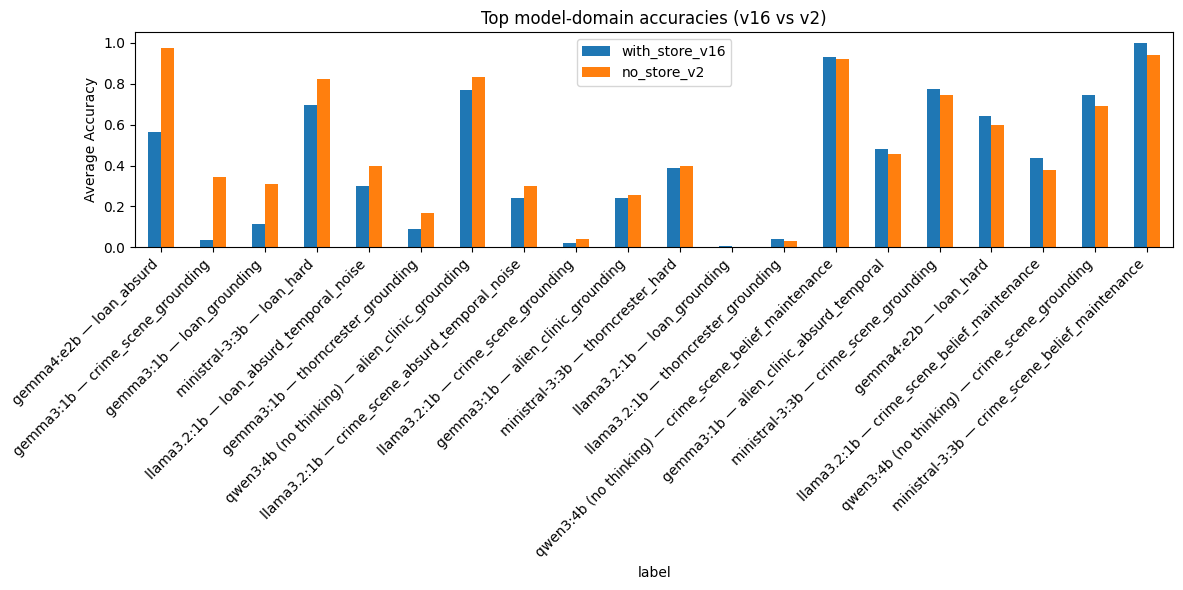

In [410]:
# Compare With_Store v16 vs No_Store v2
comp2 = df_clean.copy()
comp2[model_column] = comp2[model_column].replace(rename_map)
comp2 = comp2[comp2["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"]

if "scenario_type" not in comp2.columns:
    comp2["scenario_type"] = comp2["Domain"].apply(extract_scenario_type)

if "Prompt_Ver" in comp2.columns:
    store_mask = (comp2["Condition"] == CONFIG["with_store_label"]) & (comp2["Prompt_Ver"] == "v16")
    no_store_mask = (comp2["Condition"] == CONFIG["no_store_label"]) & (comp2["Prompt_Ver"] == "v2")
else:
    store_mask = comp2["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp2["Condition"] == CONFIG["no_store_label"]

store_grp = (
    comp2[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v16"})
)
no_store_grp = (
    comp2[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v2"})
)

merge_v16 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v16["delta_v16_v2"] = merge_v16["with_store_v16"] - merge_v16["no_store_v2"]

# counts
counts_store = comp2[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_with_store_v16"})
counts_no = comp2[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_no_store_v2"})
merge_v16 = merge_v16.merge(counts_store, on=[model_column, "Domain"], how="left").merge(counts_no, on=[model_column, "Domain"], how="left")

print("Comparison: With_Store v16  vs No_Store v2 (per model+domain)")
display(merge_v16.sort_values(by="delta_v16_v2"))

# Model-level averages for inspection (no duplicate plotting here)
model_level = merge_v16.groupby(model_column, as_index=False)[["with_store_v16", "no_store_v2"]].mean()
if "with_store_v16" not in model_level.columns:
    model_level["with_store_v16"] = float('nan')
if "no_store_v2" not in model_level.columns:
    model_level["no_store_v2"] = float('nan')

print("Model-level mean accuracies (v16 vs v2):")
display(model_level)

# Top model-domain rows by negative delta, plot their accuracies side-by-side
top = merge_v16.sort_values(by="delta_v16_v2").head(20).copy()
top['label'] = top[model_column].astype(str) + ' — ' + top['Domain'].astype(str)
fig2, ax2 = plt.subplots(figsize=(12, 6))
top_plot = top[["label", "with_store_v16", "no_store_v2"]].set_index("label")
top_plot.plot.bar(ax=ax2)
ax2.set_title('Top model-domain accuracies (v16 vs v2)')
ax2.set_ylabel('Average Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
display(fig2)

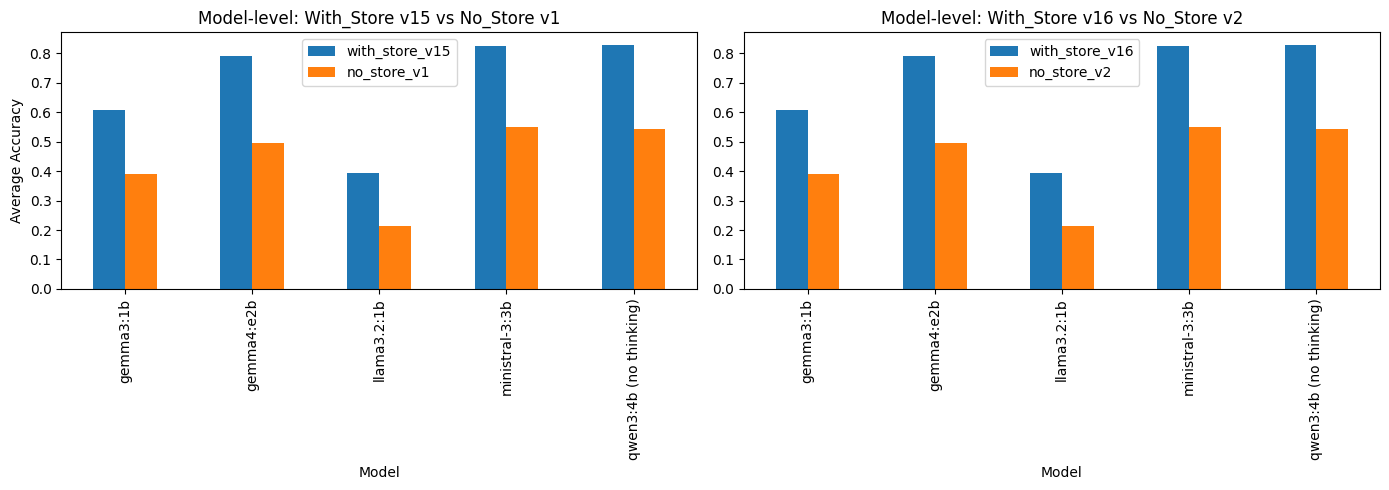

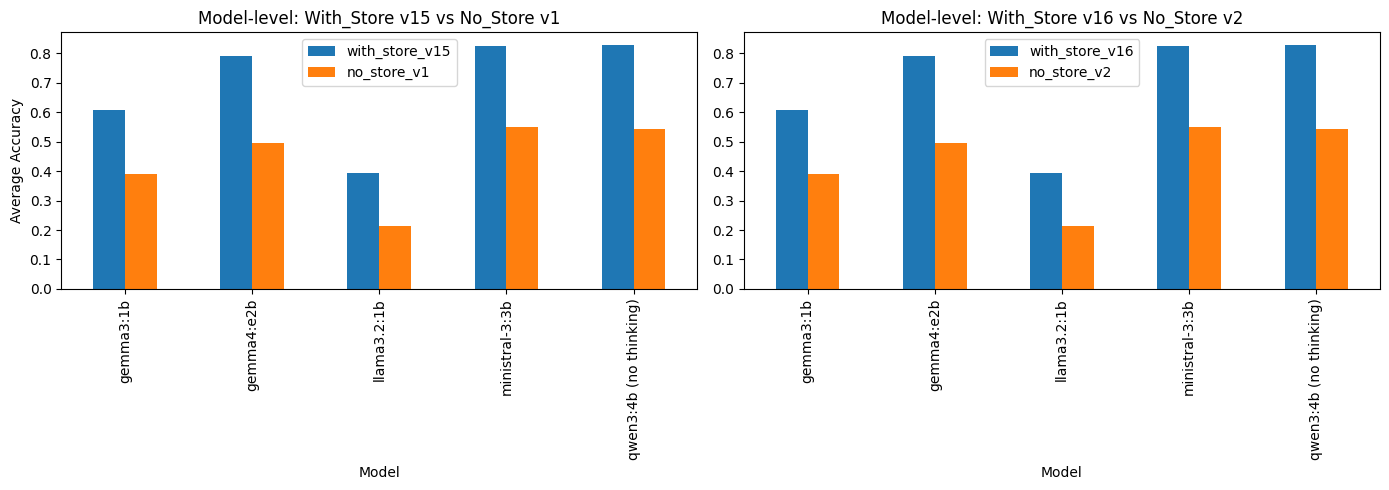

In [411]:
# Consolidated Model-level Comparison Plots for v15 and v16
import matplotlib.pyplot as plt

# prepare model-level data if available
m15 = None
m16 = None
if 'merge_v15' in globals():
    try:
        m15 = merge_v15.groupby(model_column, as_index=False)[['with_store_v15', 'no_store_v1']].mean()
    except Exception:
        m15 = None
if 'merge_v16' in globals():
    try:
        m16 = merge_v16.groupby(model_column, as_index=False)[['with_store_v16', 'no_store_v2']].mean()
    except Exception:
        m16 = None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if m15 is not None and not m15.empty:
    m15.plot.bar(x=model_column, y=['with_store_v15', 'no_store_v1'], ax=axes[0])
    axes[0].set_title('Model-level: With_Store v15 vs No_Store v1')
    axes[0].set_ylabel('Average Accuracy')
else:
    axes[0].text(0.5, 0.5, 'v15 data not available', ha='center')

if m16 is not None and not m16.empty:
    m16.plot.bar(x=model_column, y=['with_store_v16', 'no_store_v2'], ax=axes[1])
    axes[1].set_title('Model-level: With_Store v16 vs No_Store v2')
else:
    axes[1].text(0.5, 0.5, 'v16 data not available', ha='center')

plt.tight_layout()
display(fig)

Hard accuracy comparison (with_store vs no_store):


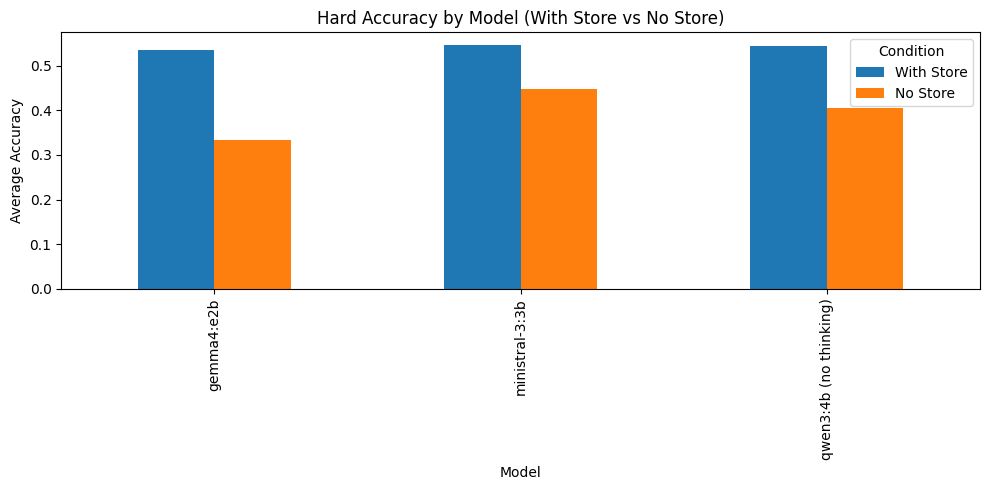

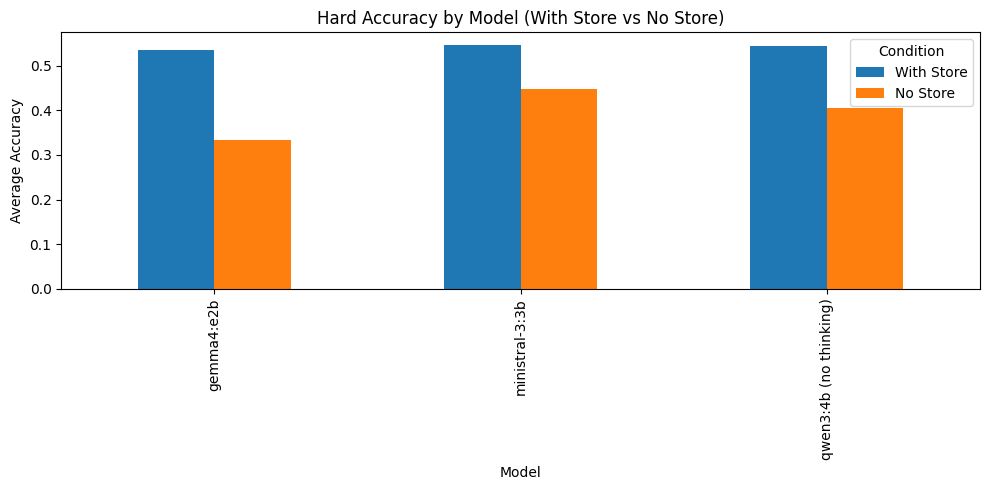

In [ ]:
# Hard Accuracy Comparison: With_Store vs No_Store for key models
import matplotlib.pyplot as plt

hard_models = ["ministral-3:3b", "gemma4:e2b", "qwen3:4b (no thinking)"]

hard_df = df_clean.copy()
hard_df[model_column] = hard_df[model_column].replace(rename_map)

required_hard_columns = [model_column, "Domain", "Condition", "Summary_Metric", "Value"]
missing_hard_columns = [col for col in required_hard_columns if col not in hard_df.columns]
if missing_hard_columns:
    raise ValueError(f"Missing required columns for hard comparison: {missing_hard_columns}")

hard_df = hard_df[
    hard_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()

hard_df = hard_df[hard_df["Domain"].astype(str).str.endswith("_hard")]
hard_df = hard_df[hard_df[model_column].isin(hard_models)]

if hard_df.empty:
    raise ValueError("No hard-accuracy rows found for the requested models")

hard_summary = (
    hard_df.groupby([model_column, "Condition"], as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "average_accuracy"})
)

hard_pivot = hard_summary.pivot(
    index=model_column,
    columns="Condition",
    values="average_accuracy",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

for column in ["with_store", "no_store"]:
    if column not in hard_pivot.columns:
        hard_pivot[column] = float("nan")

hard_pivot = hard_pivot.reset_index()
hard_pivot["delta_store_minus_no_store"] = hard_pivot["with_store"] - hard_pivot["no_store"]
hard_pivot = hard_pivot.sort_values(by=model_column)

print("Hard accuracy comparison (with_store vs no_store):")
display(hard_pivot)

ax = hard_pivot.plot(
    x=model_column,
    y=["with_store", "no_store"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Hard Accuracy by Model (With Store vs No Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.tight_layout()
display(ax.figure)


In [413]:
# Check which Domains and Models were NOT run with specific eval/baseline prompt versions
import pandas as pd

# Always reload from CSV so this cell reflects latest normalization changes
df_cov = pd.read_csv(CONFIG["csv_path"]).copy()

required_cov_cols = ["Domain", "Model", "Eval_Prompt_Ver", "Baseline_Prompt_Ver"]
missing_cov_cols = [c for c in required_cov_cols if c not in df_cov.columns]
if missing_cov_cols:
    raise ValueError(f"Coverage check is missing columns: {missing_cov_cols}")

# normalize prompt/version strings for safe comparison
df_cov["Eval_Prompt_Ver_norm"] = df_cov["Eval_Prompt_Ver"].astype(str).str.strip().str.lower()
df_cov["Baseline_Prompt_Ver_norm"] = df_cov["Baseline_Prompt_Ver"].astype(str).str.strip().str.lower()

domains = sorted(df_cov["Domain"].dropna().unique())
models = sorted(df_cov["Model"].dropna().unique())

check_eval_versions = ["v16", "v15"]
check_baseline_versions = ["v1", "v2"]

# Models that are intentionally not expected on hard scenarios.
hard_domain_suffix = "_hard"
excluded_model_tokens_for_hard = ["gemma3", "llama3.2"]

missing_eval = {}
for ev in check_eval_versions:
    present = set(df_cov.loc[df_cov["Eval_Prompt_Ver_norm"] == ev, "Domain"].dropna().unique())
    missing_eval[ev] = [d for d in domains if d not in present]

missing_baseline = {}
for bv in check_baseline_versions:
    present = set(df_cov.loc[df_cov["Baseline_Prompt_Ver_norm"] == bv, "Domain"].dropna().unique())
    missing_baseline[bv] = [d for d in domains if d not in present]

print("Domains missing Eval prompt versions:")
for ev, miss in missing_eval.items():
    print(f" - {ev}: {len(miss)} missing")
    if miss:
        display(pd.DataFrame({"Domain": miss}))

print("\nDomains missing Baseline prompt versions:")
for bv, miss in missing_baseline.items():
    print(f" - {bv}: {len(miss)} missing")
    if miss:
        display(pd.DataFrame({"Domain": miss}))

# Per-domain summary of observed prompt versions
summary_rows = []
for d in domains:
    evs = sorted(df_cov.loc[df_cov["Domain"] == d, "Eval_Prompt_Ver_norm"].dropna().unique())
    bvs = sorted(df_cov.loc[df_cov["Domain"] == d, "Baseline_Prompt_Ver_norm"].dropna().unique())
    summary_rows.append({
        "Domain": d,
        "eval_prompt_versions": ", ".join(evs),
        "baseline_prompt_versions": ", ".join(bvs),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values("Domain").reset_index(drop=True))

# Per-model missing domain coverage per version
model_missing = []
for m in models:
    mdf = df_cov[df_cov["Model"] == m]
    model_name_lc = str(m).strip().lower()
    exclude_hard_for_model = any(tok in model_name_lc for tok in excluded_model_tokens_for_hard)

    for ev in check_eval_versions:
        present = set(mdf.loc[mdf["Eval_Prompt_Ver_norm"] == ev, "Domain"].dropna().unique())
        missing = [d for d in domains if d not in present]
        if exclude_hard_for_model:
            missing = [d for d in missing if not str(d).endswith(hard_domain_suffix)]
        if missing:
            model_missing.append({
                "Model": m,
                "type": "eval",
                "version": ev,
                "missing_domains": ", ".join(missing),
            })
    for bv in check_baseline_versions:
        present = set(mdf.loc[mdf["Baseline_Prompt_Ver_norm"] == bv, "Domain"].dropna().unique())
        missing = [d for d in domains if d not in present]
        if exclude_hard_for_model:
            missing = [d for d in missing if not str(d).endswith(hard_domain_suffix)]
        if missing:
            model_missing.append({
                "Model": m,
                "type": "baseline",
                "version": bv,
                "missing_domains": ", ".join(missing),
            })

model_missing_df = pd.DataFrame(model_missing)
if not model_missing_df.empty:
    print("\nModels with missing domain coverage by version:")
    display(model_missing_df.sort_values(["Model", "type", "version"]).reset_index(drop=True))
else:
    print("\nNo model-level missing coverage detected for the checked versions.")

Domains missing Eval prompt versions:
 - v16: 4 missing


,Domain
0,alien_clinic_absurd_temporal_noise
1,crime_scene_absurd_temporal_noise
2,loan_absurd_temporal_noise
3,thorncrester_absurd_temporal_noise


 - v15: 0 missing

Domains missing Baseline prompt versions:
 - v1: 4 missing


,Domain
0,alien_clinic_absurd_temporal_noise
1,crime_scene_absurd_temporal_noise
2,loan_absurd_temporal_noise
3,thorncrester_absurd_temporal_noise


 - v2: 0 missing


,Domain,eval_prompt_versions,baseline_prompt_versions
0,alien_clinic_absurd,"v15, v16","v1, v2"
1,alien_clinic_absurd_temporal,"v15, v16","v1, v2"
2,alien_clinic_absurd_temporal_noise,v15,v2
3,alien_clinic_belief_maintenance,"v15, v16","v1, v2"
4,alien_clinic_grounding,"v15, v16","v1, v2"
5,alien_clinic_hard,"v15, v16","v1, v2"
6,crime_scene_absurd,"v15, v16","v1, v2"
7,crime_scene_absurd_temporal,"v15, v16","v1, v2"
8,crime_scene_absurd_temporal_noise,v15,v2
9,crime_scene_belief_maintenance,"v15, v16","v1, v2"



Models with missing domain coverage by version:


,Model,type,version,missing_domains
0,gemma3:1b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
1,gemma3:1b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."
2,gemma4:e2b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
3,gemma4:e2b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."
4,hoangquan456/qwen3-nothink:4b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
5,hoangquan456/qwen3-nothink:4b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."
6,llama3.2:1b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
7,llama3.2:1b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."
8,ministral-3:3b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
9,ministral-3:3b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."


In [414]:
metric_labels = {
    "AFR_Answer_Flip_Rate": "AFR",
    "Summary_Metric_Brier_Score": "Brier",
    "Summary_Metric_ECE": "ECE",
    "Summary_Metric_MacroCE": "MacroECE",
}

metrics_df = df_clean.copy()
metrics_df[model_column] = metrics_df[model_column].replace(rename_map)

metrics_df = metrics_df[metrics_df["Summary_Metric"].isin(metric_labels.keys())]

metrics_summary = (
    metrics_df.groupby([model_column, "Condition", "Summary_Metric"], as_index=False)["Value"]
    .mean()
)

metrics_table = metrics_summary.pivot(
    index=[model_column, "Condition"],
    columns="Summary_Metric",
    values="Value",
).rename(columns=metric_labels)

metrics_table = metrics_table.reset_index().sort_values(by=[model_column, "Condition"])


def format_sigfigs(value: float, sig: int = 3) -> str:
    if pd.isna(value):
        return value
    if value == 0:
        return "0"
    return f"{value:.{sig}g}"


metrics_table_display = metrics_table.copy()
for col in metric_labels.values():
    if col in metrics_table_display.columns:
        metrics_table_display[col] = metrics_table_display[col].apply(
            lambda v: format_sigfigs(v * 100, 3)
        )

display(metrics_table_display)

Summary_Metric,Model,Condition,AFR,Brier,ECE,MacroECE
0,gemma3:1b,No_Store,10.6,53.3,55.2,48.7
1,gemma3:1b,With_Store,3.89,33.8,34.8,44.3
2,gemma4:e2b,No_Store,7.2,34.2,34.5,45.6
3,gemma4:e2b,With_Store,1.81,19.8,19.9,33.7
4,llama3.2:1b,No_Store,6.78,35.4,40.4,52.4
5,llama3.2:1b,With_Store,6.19,34.6,35.2,45.7
6,ministral-3:3b,No_Store,8.18,29.7,29.4,45
7,ministral-3:3b,With_Store,2.2,16.1,16.6,34.3
8,qwen3:4b (no thinking),No_Store,7.77,39.8,39.9,46.8
9,qwen3:4b (no thinking),With_Store,1.4,16.7,16.7,33.9


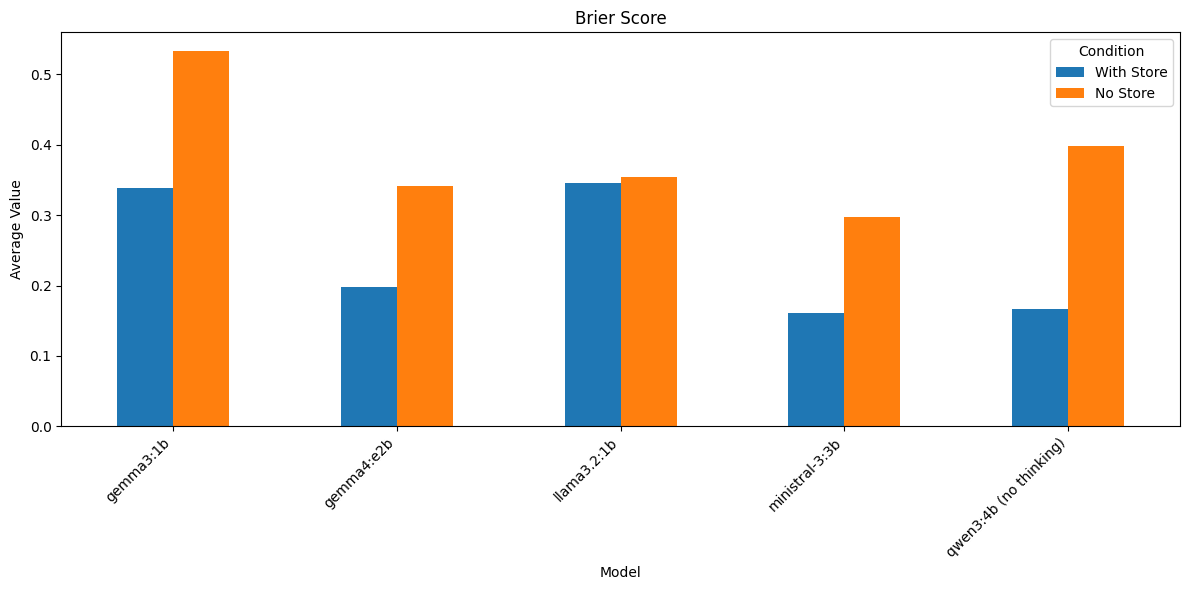

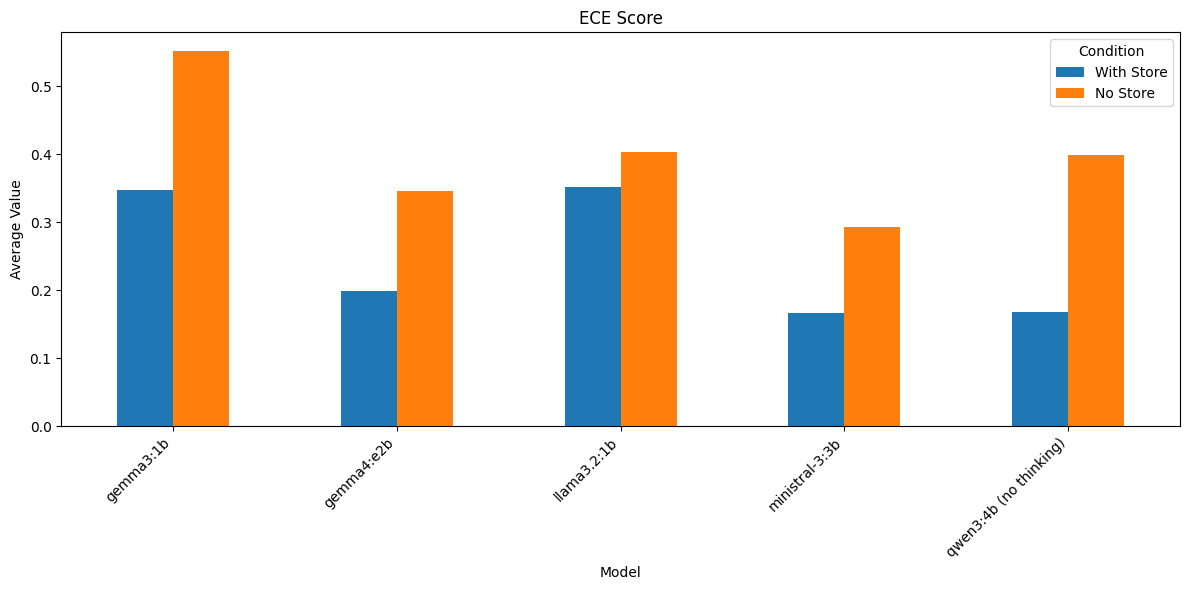

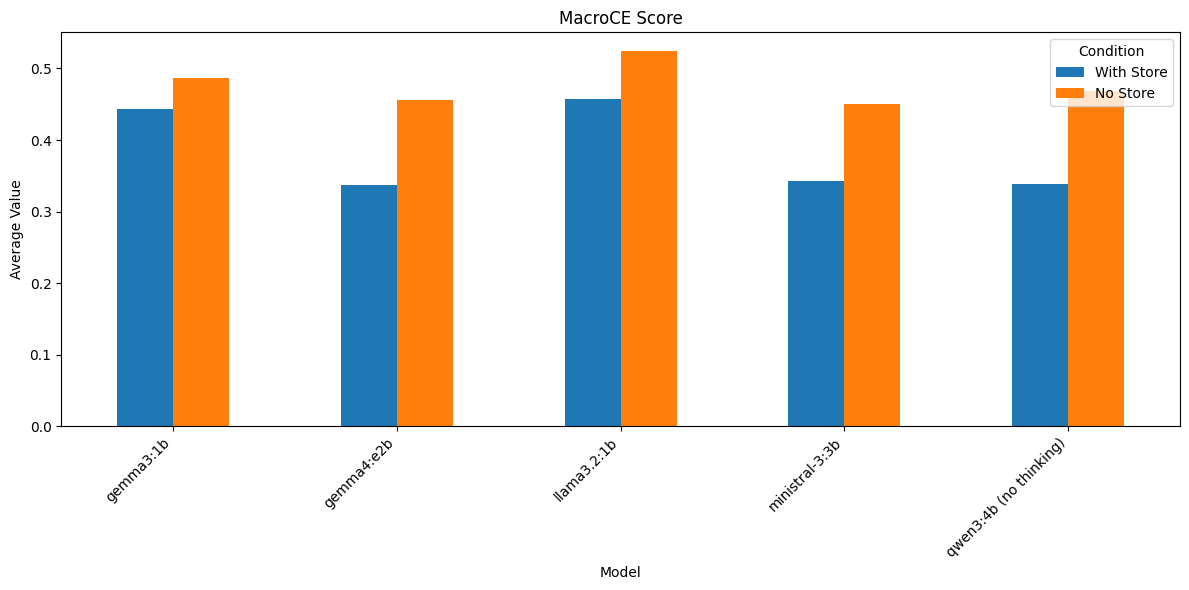

In [415]:
import matplotlib.pyplot as plt

metric_chart_map = {
    "Summary_Metric_Brier_Score": "Brier Score",
    "Summary_Metric_ECE": "ECE Score",
    "Summary_Metric_MacroCE": "MacroCE Score",
}

metric_plot_df = df_clean.copy()
metric_plot_df[model_column] = metric_plot_df[model_column].replace(rename_map)
metric_plot_df = metric_plot_df[metric_plot_df["Summary_Metric"].isin(metric_chart_map.keys())].copy()

missing_metric_columns = [
    col for col in [model_column, "Condition", "Summary_Metric", "Value"]
    if col not in metric_plot_df.columns
]
if missing_metric_columns:
    raise ValueError(f"Missing required columns for metric charts: {missing_metric_columns}")

for metric_key, metric_title in metric_chart_map.items():
    metric_subset = metric_plot_df[metric_plot_df["Summary_Metric"] == metric_key]
    metric_summary = (
        metric_subset.groupby([model_column, "Condition"], as_index=False)["Value"]
        .mean()
    )
    metric_pivot = metric_summary.pivot(
        index=model_column,
        columns="Condition",
        values="Value",
    ).rename(
        columns={
            CONFIG["with_store_label"]: "with_store",
            CONFIG["no_store_label"]: "no_store",
        }
    )

    for column in ["with_store", "no_store"]:
        if column not in metric_pivot.columns:
            metric_pivot[column] = float("nan")

    metric_pivot = metric_pivot.sort_index()
    ax = metric_pivot[["with_store", "no_store"]].plot(
        kind="bar",
        figsize=(12, 6),
    )
    ax.set_title(metric_title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Average Value")
    ax.legend(["With Store", "No Store"], title="Condition")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)


In [416]:
delta_metric = "Average_Accuracy"

delta_df = df_clean.copy()
delta_df[model_column] = delta_df[model_column].replace(rename_map)

delta_df = delta_df[
    delta_df["Summary_Metric"].astype(str).str.strip().str.lower() == delta_metric.lower()
]

delta_summary = (
    delta_df.groupby([model_column, "Domain", "Condition"], as_index=False)["Value"]
    .mean()
)

delta_pivot = delta_summary.pivot(
    index=[model_column, "Domain"],
    columns="Condition",
    values="Value",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

if "with_store" in delta_pivot.columns and "no_store" in delta_pivot.columns:
    delta_pivot["delta_store_minus_no_store"] = (
        delta_pivot["with_store"] - delta_pivot["no_store"]
    )

worst_negative = (
    delta_pivot.reset_index()
    .sort_values(by="delta_store_minus_no_store", ascending=True)
    .head(10)
)

display(worst_negative)

Condition,Model,Domain,no_store,with_store,delta_store_minus_no_store
32,gemma4:e2b,loan_absurd,0.975,0.565,-0.410
9,gemma3:1b,crime_scene_grounding,0.345,0.035,-0.310
14,gemma3:1b,loan_grounding,0.310,0.115,-0.195
81,ministral-3:3b,loan_hard,0.820,0.695,-0.125
56,llama3.2:1b,loan_absurd_temporal_noise,0.400,0.300,-0.100
19,gemma3:1b,thorncrester_grounding,0.170,0.090,-0.080
92,qwen3:4b (no thinking),alien_clinic_grounding,0.830,0.770,-0.060
51,llama3.2:1b,crime_scene_absurd_temporal_noise,0.300,0.240,-0.060
53,llama3.2:1b,crime_scene_grounding,0.040,0.020,-0.020
4,gemma3:1b,alien_clinic_grounding,0.255,0.240,-0.015


In [417]:
diagnostic_metric = "Average_Accuracy"

diagnostic_df = df_clean.copy()
diagnostic_df[model_column] = diagnostic_df[model_column].replace(rename_map)

diagnostic_df = diagnostic_df[
    diagnostic_df["Summary_Metric"].astype(str).str.strip().str.lower() == diagnostic_metric.lower()
]

diagnostic_summary = (
    diagnostic_df.groupby([model_column, "Domain", "Condition"], as_index=False)["Value"]
    .mean()
)

diagnostic_pivot = diagnostic_summary.pivot(
    index=[model_column, "Domain"],
    columns="Condition",
    values="Value",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

diagnostic_pivot["delta_store_minus_no_store"] = (
    diagnostic_pivot["with_store"] - diagnostic_pivot["no_store"]
)

model_delta_summary = (
    diagnostic_pivot.reset_index()
    .groupby(model_column, as_index=False)["delta_store_minus_no_store"]
    .agg(
        mean_delta="mean",
        median_delta="median",
        negative_count=lambda s: (s < 0).sum(),
        positive_count=lambda s: (s > 0).sum(),
    )
    .sort_values(by="mean_delta")
)

display(model_delta_summary)

,Model,mean_delta,median_delta,negative_count,positive_count
2,llama3.2:1b,0.177500,0.1525,3,17
0,gemma3:1b,0.219250,0.2500,4,16
3,ministral-3:3b,0.276042,0.2650,2,22
4,qwen3:4b (no thinking),0.288750,0.2700,1,23
1,gemma4:e2b,0.293958,0.3150,1,23


## Add Basic Tests and Assertions

In [418]:
expected_conditions = {CONFIG["with_store_label"], CONFIG["no_store_label"]}
actual_conditions = set(df_clean["Condition"].dropna().unique())

assert actual_conditions <= expected_conditions
assert len(df_with_store) + len(df_no_store) <= len(df_clean)
assert (df_with_store["Condition"] == CONFIG["with_store_label"]).all()
assert (df_no_store["Condition"] == CONFIG["no_store_label"]).all()

print("Assertions passed.")

Assertions passed.


## Insights

- **Accuracy:** Using the belief store (`with_store`) increases Average Accuracy for most models, often substantially for several models (e.g., Gemma, Minstral, Qwen variants).
- **Calibration:** Brier score, ECE, and MacroCE largely improve under `with_store`, indicating better-calibrated probabilities in many cases.
- **Scenario sensitivity:** The largest performance gains occur in the `absurd` and `absurd_temporal_noise` scenarios and in belief-maintenance/grounding tasks.
- **Model variability:** Improvements vary by model and scenario; some models show modest gains while others show large, consistent improvements.
- **Practical recommendation:** Prefer `with_store` for grounding- and belief-sensitive applications; run per-model statistical tests before making production decisions.
- **Next steps:** (1) add significance testing per model/scenario, (2) export per-model figures to `figures/`, (3) add a per-scenario CSV summary for downstream reporting.


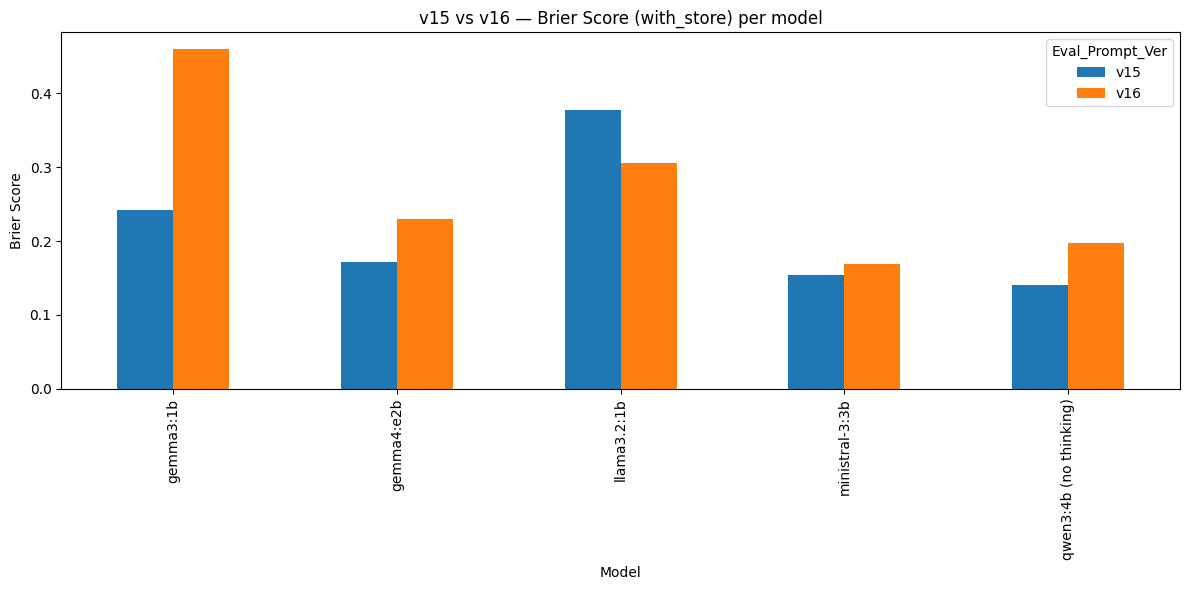

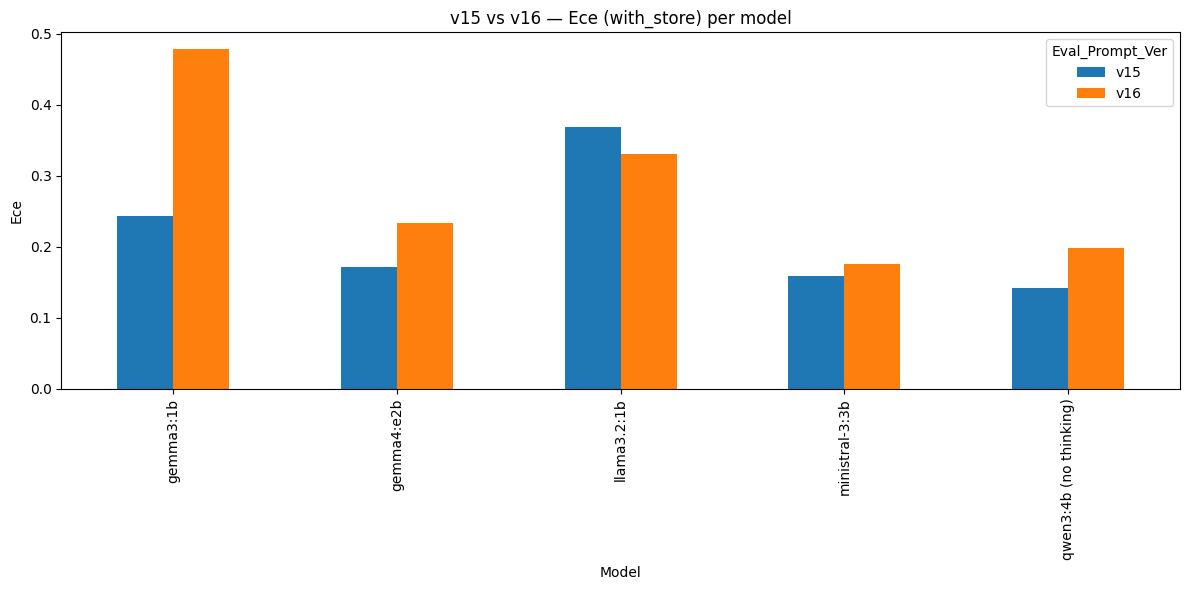

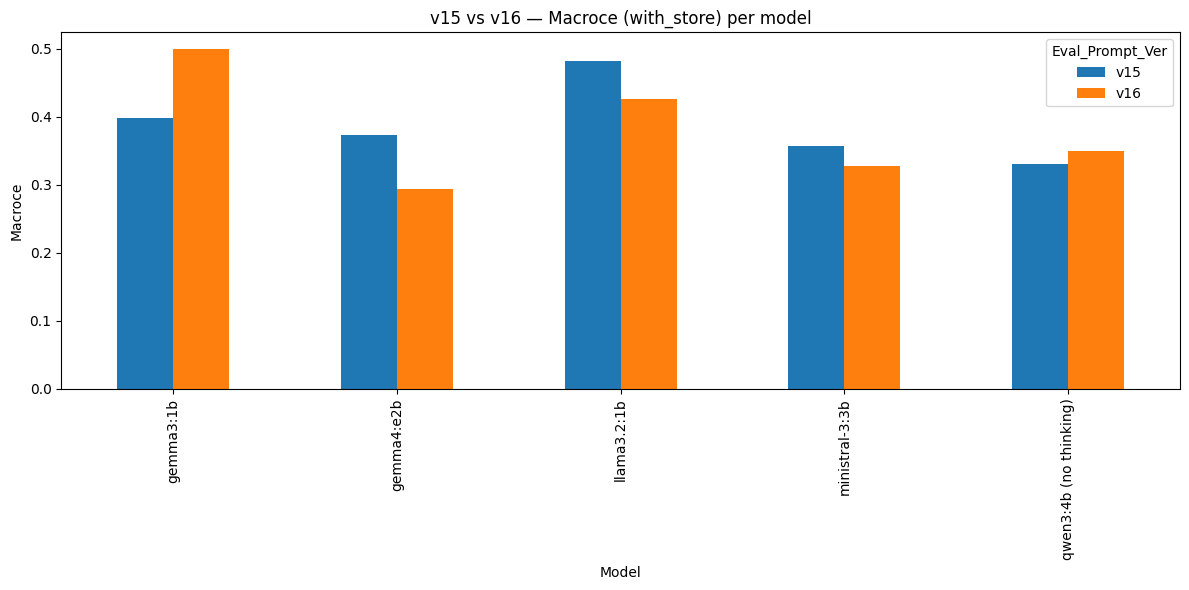

Eval_Prompt_Ver,v15,v16
Model,,
gemma3:1b,0.241517,0.459423
gemma4:e2b,0.171203,0.229242
llama3.2:1b,0.377560,0.305839
ministral-3:3b,0.153971,0.169281
qwen3:4b (no thinking),0.141064,0.197918


Eval_Prompt_Ver,v15,v16
Model,,
gemma3:1b,0.243482,0.478290
gemma4:e2b,0.171177,0.232922
llama3.2:1b,0.368721,0.330159
ministral-3:3b,0.158468,0.175521
qwen3:4b (no thinking),0.141754,0.198309


Eval_Prompt_Ver,v15,v16
Model,,
gemma3:1b,0.398761,0.498978
gemma4:e2b,0.372980,0.293330
llama3.2:1b,0.481812,0.426268
ministral-3:3b,0.356771,0.326855
qwen3:4b (no thinking),0.329911,0.348866


In [419]:
# v15 vs v16 comparison (with_store) per model across selected summary metrics using `metric_plot_df`
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Metrics to compare (common names in metric_plot_df/metrics_summary)
metrics_to_plot = [
    'AFR_Answer_Flip_Rate',
    'Summary_Metric_Brier_Score',
    'Summary_Metric_ECE',
    'Summary_Metric_MacroCE',
]

# condition label for with_store
with_label = CONFIG.get('with_store_label', 'With_Store') if isinstance(CONFIG, dict) else 'With_Store'

df = metric_plot_df.copy()
# Ensure version columns are present
ver_col = 'Eval_Prompt_Ver' if 'Eval_Prompt_Ver' in df.columns else 'Eval_Version'

# Filter to with_store only
dfw = df[df['Condition'] == with_label]

# Iterate metrics and plot v15 vs v16 per model
display(HTML('<h4>v15 vs v16 (with_store) per-model comparison for selected metrics</h4>'))
for metric in metrics_to_plot:
    if metric not in dfw['Summary_Metric'].unique():
        continue
    sub = dfw[dfw['Summary_Metric'] == metric].copy()
    # keep only v15/v16 eval versions
    sub = sub[sub[ver_col].astype(str).str.contains('v15|v16', case=False)]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index='Model', columns=ver_col, values='Value', aggfunc='mean')
    # keep v15 and v16 if present
    cols = [c for c in pivot.columns if 'v15' in str(c).lower() or 'v16' in str(c).lower()]
    if not cols:
        continue
    plot_df = pivot[cols].copy()
    # normalize column order to v15, v16 when possible
    col_order = sorted(cols, key=lambda c: ('v16' in str(c).lower(), str(c)))
    plot_df = plot_df[col_order]
    # short title
    friendly = metric.replace('Summary_Metric_','').replace('_',' ').title()
    ax = plot_df.plot(kind='bar', figsize=(12,6))
    ax.set_title(f'v15 vs v16 — {friendly} (with_store) per model')
    ax.set_ylabel(friendly)
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)

# Also display a combined table for quick reference
combined = {}
for metric in metrics_to_plot:
    sub = dfw[dfw['Summary_Metric'] == metric]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index='Model', columns=ver_col, values='Value', aggfunc='mean')
    combined[metric] = pivot

# show a sample of combined tables
for k,v in combined.items():
    display(HTML(f'<h5>{k}</h5>'))
    display(v.head(20))


In [420]:
# Inspect model_summary_v15/v16 columns to discover metric names
print('model_summary_v15 columns:')
print(list(model_summary_v15.columns))
print('\nmodel_summary_v16 columns:')
print(list(model_summary_v16.columns))

# show a small sample
from IPython.display import display
print('\nmodel_summary_v15 sample:')
display(model_summary_v15.head())
print('\nmodel_summary_v16 sample:')
display(model_summary_v16.head())


model_summary_v15 columns:
['Model', 'mean_delta', 'median_delta', 'n_domains']

model_summary_v16 columns:
['Model', 'mean_delta', 'median_delta', 'n_domains']

model_summary_v15 sample:


,Model,mean_delta,median_delta,n_domains
1,gemma4:e2b,-0.511250,-0.6700,16
2,llama3.2:1b,-0.033750,-0.0025,16
0,gemma3:1b,0.067188,0.0475,16
3,ministral-3:3b,0.149375,0.1400,16
4,qwen3:4b (no thinking),0.429375,0.4450,16



model_summary_v16 sample:


,Model,mean_delta,median_delta,n_domains
1,gemma4:e2b,-0.511250,-0.6700,16
2,llama3.2:1b,-0.033750,-0.0025,16
0,gemma3:1b,0.067188,0.0475,16
3,ministral-3:3b,0.149375,0.1400,16
4,qwen3:4b (no thinking),0.429375,0.4450,16


In [421]:
# Inspect candidate DataFrames for metric columns: merge_v15, merge_v16, m15, m16
for name in ['merge_v15','merge_v16','m15','m16','merge_v15','merge_v16']:
    if name in globals():
        df = globals()[name]
        try:
            print(f"{name} columns: {list(df.columns)}\n")
            from IPython.display import display
            display(df.head(3))
        except Exception as e:
            print(name, 'inspect error:', e)


merge_v15 columns: ['Model', 'Domain', 'with_store_v15', 'no_store_v1', 'delta_v15_v1', 'n_with_store_v15', 'n_no_store_v1']



,Model,Domain,with_store_v15,no_store_v1,delta_v15_v1,n_with_store_v15,n_no_store_v1
0,gemma3:1b,alien_clinic_absurd,0.625,0.460,0.165,2,2
1,gemma3:1b,alien_clinic_absurd_temporal,0.480,0.455,0.025,2,2
2,gemma3:1b,alien_clinic_absurd_temporal_noise,0.600,0.500,0.100,1,1


merge_v16 columns: ['Model', 'Domain', 'with_store_v16', 'no_store_v2', 'delta_v16_v2', 'n_with_store_v16', 'n_no_store_v2']



,Model,Domain,with_store_v16,no_store_v2,delta_v16_v2,n_with_store_v16,n_no_store_v2
0,gemma3:1b,alien_clinic_absurd,0.625,0.460,0.165,2,2
1,gemma3:1b,alien_clinic_absurd_temporal,0.480,0.455,0.025,2,2
2,gemma3:1b,alien_clinic_absurd_temporal_noise,0.600,0.500,0.100,1,1


m15 columns: ['Model', 'with_store_v15', 'no_store_v1']



...

,Model,with_store_v16,no_store_v2
0,gemma3:1b,0.609000,0.389750
1,gemma4:e2b,0.790625,0.496667
2,llama3.2:1b,0.392250,0.214750


merge_v15 columns: ['Model', 'Domain', 'with_store_v15', 'no_store_v1', 'delta_v15_v1', 'n_with_store_v15', 'n_no_store_v1']



,Model,Domain,with_store_v15,no_store_v1,delta_v15_v1,n_with_store_v15,n_no_store_v1
0,gemma3:1b,alien_clinic_absurd,0.625,0.460,0.165,2,2
1,gemma3:1b,alien_clinic_absurd_temporal,0.480,0.455,0.025,2,2
2,gemma3:1b,alien_clinic_absurd_temporal_noise,0.600,0.500,0.100,1,1


merge_v16 columns: ['Model', 'Domain', 'with_store_v16', 'no_store_v2', 'delta_v16_v2', 'n_with_store_v16', 'n_no_store_v2']



,Model,Domain,with_store_v16,no_store_v2,delta_v16_v2,n_with_store_v16,n_no_store_v2
0,gemma3:1b,alien_clinic_absurd,0.625,0.460,0.165,2,2
1,gemma3:1b,alien_clinic_absurd_temporal,0.480,0.455,0.025,2,2
2,gemma3:1b,alien_clinic_absurd_temporal_noise,0.600,0.500,0.100,1,1


In [422]:
# Inspect metric-related DataFrames for available metrics and versioned columns
for name in ['metric_plot_df','metrics_df','metrics_table','metrics_summary']:
    if name in globals():
        df = globals()[name]
        try:
            print(f"{name} columns: {list(df.columns)}\n")
            from IPython.display import display
            display(df.head(5))
        except Exception as e:
            print(name, 'inspect error:', e)


metric_plot_df columns: ['Timestamp', 'Domain', 'Model', 'Temp', 'Eval_Prompt_Ver', 'Baseline_Prompt_Ver', 'Runs', 'Condition', 'Summary_Metric', 'Value', 'Class_Label']



,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
19,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Summary_Metric_Brier_Score,0.015360,NaN
20,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Summary_Metric_Brier_Score,0.730600,NaN
23,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Summary_Metric_ECE,0.045246,NaN
24,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Summary_Metric_ECE,0.763305,NaN
25,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Summary_Metric_MacroCE,0.045246,NaN


metrics_df columns: ['Timestamp', 'Domain', 'Model', 'Temp', 'Eval_Prompt_Ver', 'Baseline_Prompt_Ver', 'Runs', 'Condition', 'Summary_Metric', 'Value', 'Class_Label']



,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
8,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,AFR_Answer_Flip_Rate,0.020000,NaN
9,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,AFR_Answer_Flip_Rate,0.040000,NaN
19,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Summary_Metric_Brier_Score,0.015360,NaN
20,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Summary_Metric_Brier_Score,0.730600,NaN
23,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Summary_Metric_ECE,0.045246,NaN


metrics_table columns: ['Model', 'Condition', 'AFR', 'Brier', 'ECE', 'MacroECE']



Summary_Metric,Model,Condition,AFR,Brier,ECE,MacroECE
0,gemma3:1b,No_Store,0.105561,0.533208,0.551640,0.487067
1,gemma3:1b,With_Store,0.038903,0.338364,0.347841,0.443302
2,gemma4:e2b,No_Store,0.071984,0.341684,0.345266,0.455921
3,gemma4:e2b,With_Store,0.018098,0.197585,0.199243,0.336775
4,llama3.2:1b,No_Store,0.067822,0.353853,0.403661,0.524260


metrics_summary columns: ['Model', 'Condition', 'Summary_Metric', 'Value']



,Model,Condition,Summary_Metric,Value
0,gemma3:1b,No_Store,AFR_Answer_Flip_Rate,0.105561
1,gemma3:1b,No_Store,Summary_Metric_Brier_Score,0.533208
2,gemma3:1b,No_Store,Summary_Metric_ECE,0.551640
3,gemma3:1b,No_Store,Summary_Metric_MacroCE,0.487067
4,gemma3:1b,With_Store,AFR_Answer_Flip_Rate,0.038903


Condition,With_Store,No_Store
Model,,
gemma3:1b,0.038903,0.105561
gemma4:e2b,0.018098,0.071984
llama3.2:1b,0.061931,0.067822
ministral-3:3b,0.022007,0.081766
qwen3:4b (no thinking),0.014014,0.077739


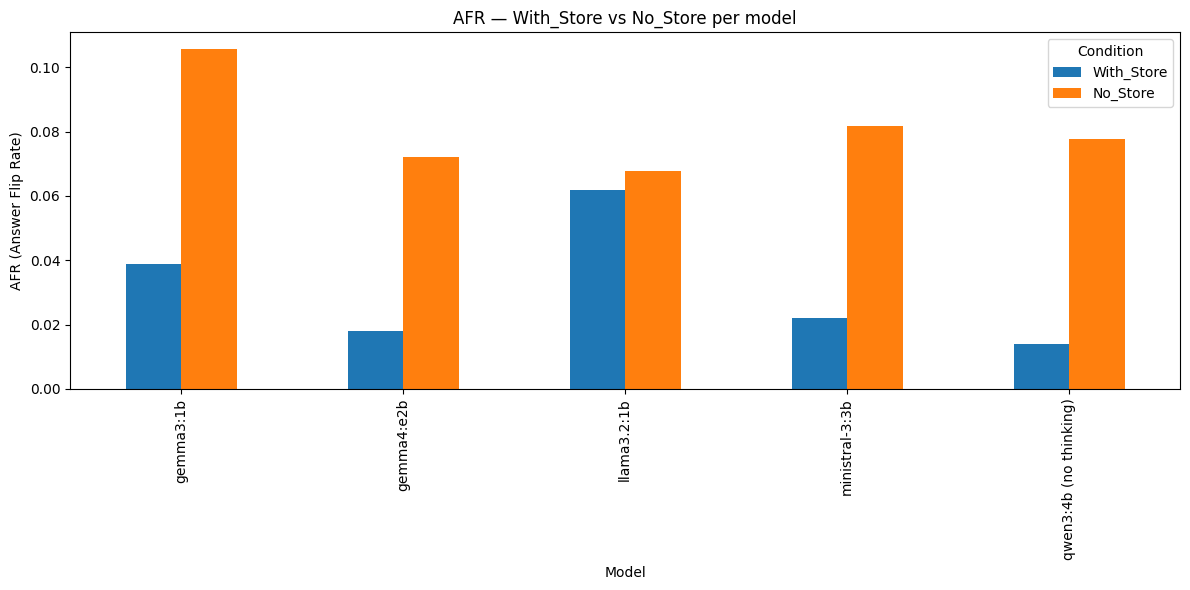

In [423]:
# AFR comparison: with_store vs no_store per model
import matplotlib.pyplot as plt
from IPython.display import display, HTML

with_label = CONFIG.get('with_store_label', 'With_Store') if isinstance(CONFIG, dict) else 'With_Store'
no_label = CONFIG.get('no_store_label', 'No_Store') if isinstance(CONFIG, dict) else 'No_Store'

df = metrics_table.copy()
# handle possible AFR column names
afr_col = 'AFR' if 'AFR' in df.columns else ('AFR_Answer_Flip_Rate' if 'AFR_Answer_Flip_Rate' in df.columns else None)
if afr_col is None:
    raise RuntimeError('AFR column not found in metrics_table')

pivot = df.pivot_table(index='Model', columns='Condition', values=afr_col, aggfunc='mean')
# normalize presence of expected condition labels
for col in [with_label, no_label]:
    if col not in pivot.columns:
        # try variations: 'With_Store'/'No_Store'
        if 'With_Store' in pivot.columns and with_label not in pivot.columns:
            pivot[with_label] = pivot['With_Store']
        if 'No_Store' in pivot.columns and no_label not in pivot.columns:
            pivot[no_label] = pivot['No_Store']

# ensure both columns exist; fill missing with NaN
cols = [c for c in [with_label, no_label] if c in pivot.columns]
plot_df = pivot.reindex(columns=cols)
plot_df = plot_df.rename(columns={with_label: 'With_Store', no_label: 'No_Store'})

display(HTML('<h4>AFR (Answer Flip Rate): With_Store vs No_Store per model</h4>'))
display(plot_df.head(40))

ax = plot_df.plot(kind='bar', figsize=(12,6))
ax.set_title('AFR — With_Store vs No_Store per model')
ax.set_ylabel('AFR (Answer Flip Rate)')
plt.tight_layout()
plt.show()
plt.close(ax.figure)


In [429]:
# F1 (v15 vs v16) comparison for With_Store per model
import matplotlib.pyplot as plt
from IPython.display import display, HTML

with_label = CONFIG.get('with_store_label', 'With_Store') if isinstance(CONFIG, dict) else 'With_Store'

df = metric_plot_df.copy()
# find candidate F1 metric names
unique_metrics = set(df['Summary_Metric'].unique())
f1_candidates = [m for m in unique_metrics if 'f1' in m.lower() or 'f-1' in m.lower() or 'f score' in m.lower() or 'f1' in m.lower()]

if not f1_candidates:
    display(HTML('<b>No F1-like Summary_Metric found in metric_plot_df.</b>'))
else:
    # prefer exact 'F1' if present
    metric_name = None
    for cand in ['F1','F1_Score','Summary_Metric_F1','F1-Score']:
        for m in f1_candidates:
            if cand.lower() == m.lower():
                metric_name = m
                break
        if metric_name:
            break
    if metric_name is None:
        metric_name = sorted(f1_candidates)[0]

    display(HTML(f'<h4>Using Summary_Metric = {metric_name} for F1 comparison (With_Store)</h4>'))
    sub = df[(df['Summary_Metric'] == metric_name) & (df['Condition'] == with_label)].copy()
    ver_col = 'Eval_Prompt_Ver' if 'Eval_Prompt_Ver' in sub.columns else ('Eval_Version' if 'Eval_Version' in sub.columns else None)
    if ver_col is None:
        raise RuntimeError('No version column found (Eval_Prompt_Ver or Eval_Version)')
    sub = sub[sub[ver_col].astype(str).str.contains('v15|v16', case=False)]
    if sub.empty:
        display(HTML('<b>No rows found for the selected metric and versions v15/v16.</b>'))
    else:
        pivot = sub.pivot_table(index='Model', columns=ver_col, values='Value', aggfunc='mean')
        cols = [c for c in pivot.columns if 'v15' in str(c).lower() or 'v16' in str(c).lower()]
        plot_df = pivot[cols].copy()
        # ensure consistent order
        col_order = sorted(cols, key=lambda c: ('v16' in str(c).lower(), str(c)))
        plot_df = plot_df[col_order]
        # rename columns to v15/v16
        plot_df.columns = ['v15' if 'v15' in str(c).lower() else 'v16' for c in plot_df.columns]
        display(plot_df.head(40))
        ax = plot_df.plot(kind='bar', figsize=(12,6))
        ax.set_title(f'F1 (v15 vs v16) — {metric_name} (With_Store) per model')
        ax.set_ylabel('F1')
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


In [425]:
# Inspect raw dataframes for prediction/label columns to compute F1
print('df_clean columns:')
print(list(df_clean.columns))
print('\nper_run_var columns:')
print(list(per_run_var.columns) if 'per_run_var' in globals() else 'per_run_var not present')
print('\nper_run_var_df columns:')
print(list(per_run_var_df.columns) if 'per_run_var_df' in globals() else 'per_run_var_df not present')

# Show small samples to look for label/prediction fields
from IPython.display import display
if 'df_clean' in globals():
    display(df_clean.head(3))
if 'per_run_var' in globals():
    try:
        display(per_run_var.head(3))
    except Exception:
        print('could not display per_run_var')


df_clean columns:
['Timestamp', 'Domain', 'Model', 'Temp', 'Eval_Prompt_Ver', 'Baseline_Prompt_Ver', 'Runs', 'Condition', 'Summary_Metric', 'Value', 'Class_Label']

per_run_var columns:
['Model', 'scenario_type', 'Condition', 'std_accuracy']

per_run_var_df columns:
['Timestamp', 'Domain', 'Model', 'Temp', 'Eval_Prompt_Ver', 'Baseline_Prompt_Ver', 'Runs', 'Condition', 'Summary_Metric', 'Value', 'Class_Label', 'scenario_type']


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Average_Accuracy,0.9500,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Average_Accuracy,0.2100,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Variance_Raw_Score,0.2778,NaN


,Model,scenario_type,Condition,std_accuracy
0,gemma3:1b,absurd,No_Store,0.213738
1,gemma3:1b,absurd,With_Store,0.240476
2,gemma3:1b,absurd_temporal,No_Store,0.117587


,v15,v16
Model,,
gemma3:1b,0.449825,NaN
gemma4:e2b,0.425475,0.52567
hoangquan456/qwen3-nothink:4b,0.466083,0.33846
llama3.2:1b,0.225745,NaN
ministral-3:3b,0.568208,0.29480


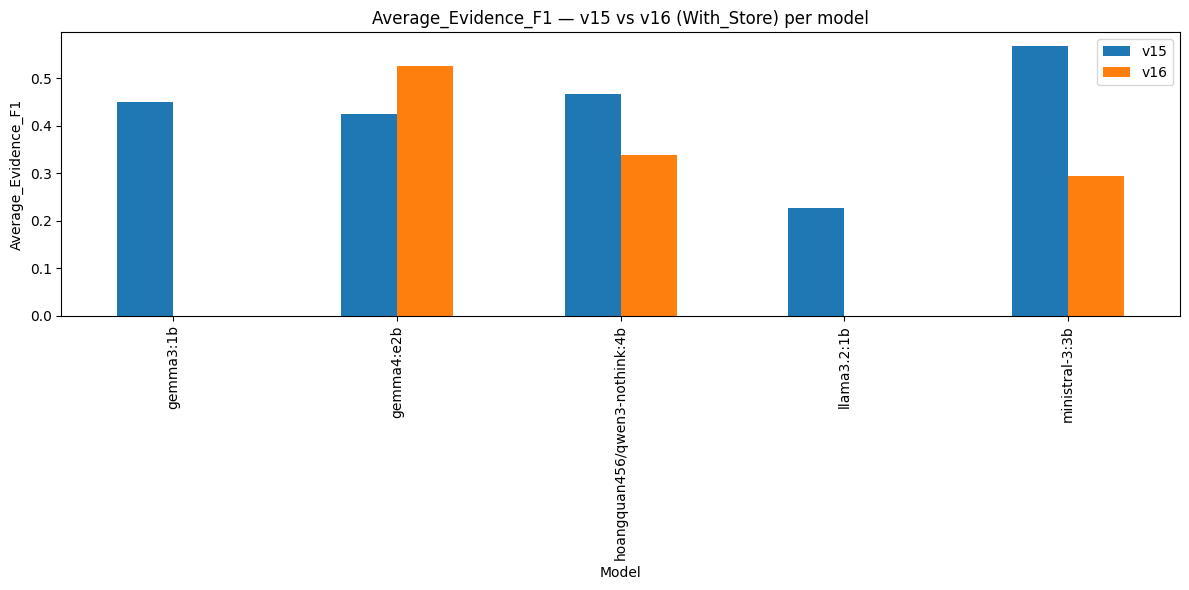

In [430]:
# Average_Evidence_F1: compare v15 vs v16 (With_Store) per model using the normalized CSV
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

csv_path = 'eval_results_normalized.csv'
metric = 'Average_Evidence_F1'

# read normalized results
try:
    df_csv = pd.read_csv(csv_path)
except Exception as e:
    raise RuntimeError(f'Could not read {csv_path}: {e}')

# Support either Summary_Metric rows or a direct column
if 'Summary_Metric' in df_csv.columns:
    sub = df_csv[df_csv['Summary_Metric'] == metric].copy()
else:
    if metric in df_csv.columns:
        sub = df_csv[['Model','Condition','Eval_Prompt_Ver',metric]].copy()
        sub = sub.rename(columns={metric:'Value'})
        sub['Summary_Metric'] = metric
    else:
        raise RuntimeError(f'{metric} not found in {csv_path}')

with_label = CONFIG.get('with_store_label', 'With_Store') if isinstance(CONFIG, dict) else 'With_Store'
ver_col = 'Eval_Prompt_Ver' if 'Eval_Prompt_Ver' in sub.columns else ('Eval_Version' if 'Eval_Version' in sub.columns else None)
if ver_col is None:
    raise RuntimeError('No version column found in CSV (Eval_Prompt_Ver or Eval_Version)')

subw = sub[sub['Condition'] == with_label].copy()
subw = subw[subw[ver_col].astype(str).str.contains('v15|v16', case=False)]
if subw.empty:
    display(HTML(f'<b>No rows found for {metric} with Condition={with_label} and versions v15/v16 in {csv_path}.</b>'))
else:
    pivot = subw.pivot_table(index='Model', columns=ver_col, values='Value', aggfunc='mean')
    cols = [c for c in pivot.columns if 'v15' in str(c).lower() or 'v16' in str(c).lower()]
    if not cols:
        display(HTML(f'<b>No v15/v16 columns detected in pivot for {metric}.</b>'))
    else:
        # order v15 then v16 if present
        col_order = sorted(cols, key=lambda c: ('v16' in str(c).lower(), str(c)))
        plot_df = pivot[col_order].copy()
        # normalize column names to v15/v16
        plot_df.columns = ['v15' if 'v15' in str(c).lower() else 'v16' for c in plot_df.columns]
        display(HTML(f'<h4>{metric}: v15 vs v16 (With_Store) per model</h4>'))
        display(plot_df.head(40))
        ax = plot_df.plot(kind='bar', figsize=(12,6))
        ax.set_title(f'{metric} — v15 vs v16 (With_Store) per model')
        ax.set_ylabel(metric)
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


## Why MacroCE Can Be Much Higher Than ECE

- **Aggregation difference:** ECE is typically a sample-weighted expected calibration error computed over confidence bins (so well-calibrated majority classes dominate); MacroCE is the mean of per-class calibration errors (each class contributes equally). This makes MacroCE much more sensitive to poorly-calibrated rare classes.

- **Class imbalance:** When classes are imbalanced and rare classes have large calibration errors, MacroCE inflates because it gives those rare classes equal weight; ECE will down-weight their contribution.

- **Top-label vs per-class probabilities:** ECE is often computed on the top-predicted confidence only; MacroCE is commonly computed using one-vs-rest per-class probabilities (or class-wise calibration), which exposes miscalibration in non-top probabilities that ECE can miss.

- **Binning and implementation choices:** Differences in bin count, binning strategy (equal-width vs equal-frequency), and whether error is averaged per-class or per-bin can change magnitudes; MacroCE implementations that average many small class-wise errors can produce larger values than a single ECE.

Quick checks you can run in the notebook to verify the cause:

- Compute per-class calibration errors and class supports (counts) and inspect which classes are driving MacroCE:

```python
# requires per-example predicted probabilities `y_prob` and labels `y_true`
import numpy as np
from sklearn.calibration import calibration_curve

classes = np.unique(y_true)
per_class_ce = {}
class_counts = {}
for cls in classes:
    mask = (y_true == cls)
    class_counts[cls] = mask.sum()
    probs = y_prob[mask, cls]
    if len(probs) == 0:
        per_class_ce[cls] = np.nan
        continue
    # simple bin-based CE (absolute difference between accuracy and confidence)
    prob_bins = np.linspace(0,1,11)
    bin_idx = np.digitize(probs, prob_bins, right=True)
    ce = 0.0
    total = 0
    for b in range(1, len(prob_bins)):
        bmask = bin_idx == b
        if bmask.sum() == 0:
            continue
        acc = probs[bmask].mean() >= 0.5  # if using hard labels; adapt if needed
        conf = probs[bmask].mean()
        ce += bmask.sum() * abs(acc - conf)
        total += bmask.sum()
    per_class_ce[cls] = ce / total if total>0 else np.nan

# Report classes with high CE but low support
import pandas as pd
report = pd.DataFrame.from_dict({'ce':per_class_ce,'count':class_counts}, orient='index')
report.sort_values(['ce','count'], ascending=[False, True]).head(20)
```

- Plot per-class reliability diagrams (or a grid of them). If rare classes show large gaps in reliability diagrams, they explain a high MacroCE.

Conclusion: large MacroCE vs ECE usually signals uneven per-class calibration (especially on low-support classes) or that MacroCE uses per-class (one-vs-rest) probabilities while ECE only evaluates top-label confidence. Address by inspecting per-class CE and supports, or report a weighted MacroCE (weighted by support) if you want a metric closer to ECE.

## MacroCE implementation and diagnostic

The evaluation code computes MacroCE using the following implementation (see `evaluation/eval_harness.py`):

- ICE_pos = mean(1 - confidence) over all *correct* predictions
- ICE_neg = mean(confidence) over all *incorrect* predictions
- MacroCE = 0.5 * (ICE_pos + ICE_neg)

Notes:
- This MacroCE is not a per-class average. It balances calibration on correct vs incorrect predictions and therefore can be large when the model is systematically overconfident on incorrect answers (high ICE_neg) or underconfident on correct answers (high ICE_pos), even if those cases are relatively rare.
- ECE (the other calibration metric we compute) is a sample-weighted bin-based expected calibration error and can remain small while MacroCE is large.

Below we add a diagnostic that identifies models and domains where MacroCE notably exceeds ECE (a strong hint that ICE_neg or ICE_pos is driving MacroCE up). If you want per-class ICE diagnostics we need per-example predicted probabilities; see the code comments below for how to compute ICE_pos/ICE_neg from per-example `(prob, outcome)` pairs.

In [427]:
# Diagnostic: show MacroCE vs ECE per model and domain, and flag large deltas
import pandas as pd
from IPython.display import display, HTML

# Prefer `metrics_table` if available, otherwise construct from metrics_summary
if 'metrics_table' in globals():
    mt = metrics_table.copy()
else:
    mt = metrics_summary.pivot(index='Model', columns='Condition', values='Value').reset_index()

# handle column name variations
ece_col = None
macro_col = None
for c in mt.columns:
    if str(c).lower().strip() in ['ece','summary_metric_ece']:
        ece_col = c
    if str(c).lower().strip() in ['macroece','macroce','summary_metric_macroce']:
        macro_col = c

if ece_col is None or macro_col is None:
    display(HTML('<b>ECE or MacroCE column not found in `metrics_table`.</b>'))
else:
    # group by model & domain if domain present
    cols_needed = ['Model']
    if 'Domain' in mt.columns:
        cols_needed.append('Domain')
    cols_needed += [ece_col, macro_col, 'Condition'] if 'Condition' in mt.columns else [ece_col, macro_col]

    df = mt.copy()
    # Keep only rows where both metrics present
    df = df.dropna(subset=[ece_col, macro_col])

    # Compute delta = MacroCE - ECE
    df['delta_macro_minus_ece'] = df[macro_col] - df[ece_col]

    # Focus on With_Store rows to match user's interest
    with_label = CONFIG.get('with_store_label', 'With_Store') if isinstance(CONFIG, dict) else 'With_Store'
    if 'Condition' in df.columns:
        dfw = df[df['Condition'] == with_label].copy()
    else:
        dfw = df.copy()

    display(HTML('<h4>Top models where MacroCE − ECE is largest (With_Store)</h4>'))
    if 'Domain' in dfw.columns:
        display(dfw.sort_values('delta_macro_minus_ece', ascending=False)[['Model','Domain', macro_col, ece_col, 'delta_macro_minus_ece']].head(30))
    else:
        display(dfw.sort_values('delta_macro_minus_ece', ascending=False)[['Model', macro_col, ece_col, 'delta_macro_minus_ece']].head(30))

    # Show per-model average delta across domains
    if 'Domain' in dfw.columns:
        avg_delta = (
            dfw.groupby('Model', as_index=False)['delta_macro_minus_ece'].mean().sort_values('delta_macro_minus_ece', ascending=False)
        )
        display(HTML('<h4>Mean MacroCE − ECE per model (With_Store)</h4>'))
        display(avg_delta)

    display(HTML('<p>If MacroCE−ECE is large for a model, that suggests ICE_pos or ICE_neg (as computed in evaluation/eval_harness.py) is high — likely overconfidence on incorrect predictions or underconfidence on correct ones.</p>'))


Summary_Metric,Model,MacroECE,ECE,delta_macro_minus_ece
7,ministral-3:3b,0.343173,0.166219,0.176953
9,qwen3:4b (no thinking),0.338527,0.167461,0.171066
3,gemma4:e2b,0.336775,0.199243,0.137532
5,llama3.2:1b,0.457126,0.351582,0.105543
1,gemma3:1b,0.443302,0.347841,0.095461


In [433]:
# Calculate average Extraction Failure Rate (EFR) per model (and per condition when available)
import pandas as pd
from IPython.display import display

# Prefer existing in-memory DataFrames if present, else fall back to CSV
if 'metrics_df' in globals() and 'Summary_Metric' in metrics_df.columns:
    src = metrics_df.copy()
elif 'df' in globals() and 'Summary_Metric' in df.columns:
    src = df.copy()
elif 'df_clean' in globals() and 'Summary_Metric' in df_clean.columns:
    src = df_clean.copy()
else:
    csv_path = "eval_results_normalized.csv"
    try:
        src = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Fallback CSV not found: {csv_path}")
        src = pd.DataFrame()

if src.empty:
    print('No source DataFrame available to compute EFR.')
else:
    # Ensure Summary_Metric and Value columns exist
    if 'Summary_Metric' not in src.columns:
        print('Source DataFrame does not contain a "Summary_Metric" column.')
    else:
        # Filter rows that refer to extraction failure rate
        mask = src['Summary_Metric'].astype(str).str.contains('EFR_Extraction_Failure_Rate', na=False)
        efr = src[mask].copy()
        if efr.empty:
            print('No EFR rows found in the source DataFrame.')
        else:
            # Convert Value to numeric
            efr['Value'] = pd.to_numeric(efr['Value'], errors='coerce')
            # Compute per-model, per-condition averages if 'Condition' exists
            if 'Condition' in efr.columns:
                per_model_cond = (
                    efr.groupby(['Model', 'Condition'], dropna=False)['Value']
                       .mean()
                       .reset_index()
                       .rename(columns={'Value': 'Avg_EFR'})
                )
                print('Average EFR per model and condition:')
                display(per_model_cond.sort_values(['Avg_EFR'], ascending=False).style.format({'Avg_EFR':'{:.4f}'}))
            # Also compute overall per-model average
            per_model_overall = (
                efr.groupby('Model', dropna=False)['Value']
                   .mean()
                   .reset_index()
                   .rename(columns={'Value': 'Avg_EFR_Overall'})
            )
            print('\nAverage EFR per model (overall):')
            display(per_model_overall.sort_values('Avg_EFR_Overall', ascending=False).style.format({'Avg_EFR_Overall':'{:.4f}'}))


No EFR rows found in the source DataFrame.


In [437]:
# EFR: explicitly read CSV and show With_Store vs No_Store average per model
import pandas as pd
from IPython.display import display

csv_path = 'eval_results_normalized.csv'
try:
    src = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f'CSV not found: {csv_path}')
    src = pd.DataFrame()

if src.empty:
    print('Source CSV is empty or missing.')
else:
    if 'Summary_Metric' not in src.columns:
        print('CSV missing Summary_Metric column')
    else:
        efr = src[src['Summary_Metric'] == 'EFR_Extraction_Failure_Rate'].copy()
        if efr.empty:
            print('No EFR_Extraction_Failure_Rate rows found in CSV')
        else:
            efr['Value'] = pd.to_numeric(efr['Value'], errors='coerce')
            if 'Condition' not in efr.columns:
                efr['Condition'] = 'Unknown'
            # Normalize Condition labels
            efr['Condition'] = efr['Condition'].replace({'WithStore':'With_Store','NoStore':'No_Store'})
            pivot = (
                efr.pivot_table(index='Model', columns='Condition', values='Value', aggfunc='mean')
                   .fillna(0.0)
            )
            # Reorder columns
            cols_order = [c for c in ['With_Store','No_Store'] if c in pivot.columns]
            other_cols = [c for c in pivot.columns if c not in cols_order]
            pivot = pivot[cols_order + other_cols]
            pivot = pivot.reset_index()
            print('Average EFR per model (With_Store vs No_Store):')
            display(pivot.round(4))


Average EFR per model (With_Store vs No_Store):


Condition,Model,With_Store,No_Store
0,gemma3:1b,0.1817,0.1147
1,gemma4:e2b,0.0507,0.2548
2,hoangquan456/qwen3-nothink:4b,0.0277,0.0311
3,llama3.2:1b,0.1919,0.4325
4,ministral-3:3b,0.0186,0.0991
